In [1]:
# ============================================================
# BLOQUE 1 - CONFIGURACIÓN Y CARGA DE DATOS
# ============================================================

import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# -----------------------------
# Si estás en Colab, monta Drive
# -----------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except:
    IN_COLAB = False

# -----------------------------
# Paths
# -----------------------------
BASE_PATH = "/content/drive/MyDrive/ColabData" if IN_COLAB else "."

PATH_MXMH = f"{BASE_PATH}/mxmh_survey_results.csv"
PATH_SPOTIFY = f"{BASE_PATH}/Music_recommendation_withProperRagas.csv"

# -----------------------------
# Carga de datos
# -----------------------------
df_raw = pd.read_csv(PATH_MXMH)
df_spotify_raw = pd.read_csv(PATH_SPOTIFY)

print("MXMH raw shape:", df_raw.shape)
print("Spotify raw shape:", df_spotify_raw.shape)

display(df_raw.head())
display(df_spotify_raw.head())

Mounted at /content/drive
MXMH raw shape: (736, 33)
Spotify raw shape: (32833, 27)


/tmp/ipykernel_2345/3700596178.py:42: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_spotify_raw = pd.read_csv(PATH_SPOTIFY)


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,Mental_Health_Label,raga_name,raga_label,instrument
0,697MjF1454XKvZmTuqkWmD,I Miss You,Jeriqo,45,2vJ6FDg6ZMS56U8Wbiw2Oz,I Miss You,2019-02-05,Pop Hits 2000-2019,6mtYuOxzl58vSGnEDtZ9uB,edm,...,0.004910,0.000013,0.0816,0.415,174.026,216347,Normal/Unclassified,NaN,Bageshree,Unknown
1,3x2bXiU0o4WbsPkawXlfDA,Who Are You,The Who,17,6LRJF97hgXHj8uMLHyCDbh,Who Are You (Remastered),1978-08-18,House Of The Rising Sun,1bMYfBHYBCRHY5LGkjlpSy,rock,...,0.265000,0.003130,0.1060,0.489,156.371,378707,Normal/Unclassified,NaN,Yaman,Guitar/Drums
2,0jEaPBjFAWjQTMVouRwaHi,Happy,The Beef Seeds,30,4IQn9XpweytNX2cUe2NBUH,Keepin' it Beefy,2015-01-19,Bluegrass Covers,37i9dQZF1DX56crgoe4TG3,r&b,...,0.665000,0.000000,0.1270,0.932,86.529,218044,Bipolar (Mania),NaN,Kafi,Unknown
3,5EKUb1FKsyYVaSXb41YBIj,ONE,Rev Theory,35,0gGic19XvEiHKKWBV7M4YM,ONE,2020-01-15,Rock Hard,37i9dQZF1DWWJOmJ7nRx0C,rock,...,0.000006,0.000000,0.3030,0.520,90.016,208196,Normal/Unclassified,NaN,Bageshree,Guitar/Drums
4,300DUx4tdtCdGEUXR032jA,Palace/Curse,The Internet,62,69g3CtOVg98TPOwqmI2K7Q,Ego Death,2015-06-26,NEO-soul,3q3M4VCymcMoxJ3Tl7mRqN,r&b,...,0.035100,0.000727,0.2430,0.261,67.104,440013,Normal/Unclassified,NaN,Kafi,Unknown


## Bloque 1 — Configuración del entorno y carga de datos

### Objetivo del bloque
En este primer bloque se prepara el entorno de trabajo y se realiza la carga inicial de las dos fuentes de datos del proyecto:

- **Dataset MxMH (Music & Mental Health)**: base principal para modelar la probabilidad de mejora percibida del usuario.
- **Dataset Spotify**: catálogo musical auxiliar que se utilizará más adelante para transformar reglas abstractas de recomendación en canciones reales.

### Qué se hace exactamente
1. **Importación de librerías**
   - Se cargan librerías para manipulación de datos (`pandas`, `numpy`), visualización (`matplotlib`) y modelado (`scikit-learn`, `imblearn`).
   - También se importan utilidades necesarias para el clustering y el modelo final.

2. **Montaje de Google Drive en Colab**
   - Se conecta el notebook con Google Drive para evitar cargas manuales repetidas en cada sesión.
   - Esto mejora la **persistencia**, la **reproducibilidad** y la **trazabilidad** del proyecto.

3. **Definición de rutas**
   - Se centralizan las rutas de los archivos en variables (`PATH_MXMH`, `PATH_SPOTIFY`), lo que facilita mantenimiento y reutilización del notebook.

4. **Carga de datasets**
   - Se leen ambos archivos CSV en dataframes:
     - `df_raw`: datos originales de MxMH
     - `df_spotify_raw`: datos originales del catálogo musical
   - Se inspeccionan sus dimensiones y primeras filas para validar que la ingesta se ha realizado correctamente.

### Por qué este bloque es importante
Este bloque establece la base del proyecto. Antes de limpiar, transformar o modelar, es necesario garantizar que:

- los datos están accesibles,
- las rutas son correctas,
- el entorno está preparado,
- y la ingesta inicial funciona sin errores.

En términos de arquitectura, este bloque corresponde a la **fase de inicialización e ingestión**, y es esencial para asegurar que el resto del pipeline se ejecute de forma consistente.

### Resultado esperado
Al finalizar este bloque, debemos tener disponibles en memoria:

- `df_raw` → dataset MxMH sin transformar
- `df_spotify_raw` → dataset Spotify sin transformar

Estos serán los inputs de los siguientes bloques del pipeline.

In [2]:
# ============================================================
# BLOQUE A - CARGA DEL NUEVO CSV DEL FORMULARIO
# ============================================================

PATH_NEW_FORM = f"{BASE_PATH}/musica_bienestar_results.csv"

df_new_raw = pd.read_csv(PATH_NEW_FORM)

print("Shape nuevo dataset:", df_new_raw.shape)
print("\nColumnas nuevo dataset:")
print(df_new_raw.columns.tolist())

display(df_new_raw.head())

Shape nuevo dataset: (120, 33)

Columnas nuevo dataset:
['Marca temporal', '  ¿Aceptas participar de forma anónima en este estudio sobre música y bienestar?  ', 'Edad', '  ¿Cuál es tu servicio de streaming principal?  ', '  ¿Cuántas horas al día escuchas música?  ', '¿Escuchas música mientras trabajas?', '¿Tocas algún intrumento musical?', '¿Compones música?', '¿Sueles explorar música nueva? (nuevos artistas / géneros)', '¿Escuchas música en idiomas que no son tu lengua nativa?  ', 'Si conoces el ritmo aproximado de la música que escuchas (BPM), indícalo en número.\n\nEjemplo:\n- Música relajada: 60–90 BPM\n- Música pop: 100–130 BPM\n- Música electrónica: 120–150 BPM\n\n(Si no lo sabes, deja este campo en blanco)', '  ¿Cuál es tu género musical favorito?  ', '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Classical]', '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Country]', '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [EDM (E

,Marca temporal,¿Aceptas participar de forma anónima en este estudio sobre música y bienestar?,Edad,¿Cuál es tu servicio de streaming principal?,¿Cuántas horas al día escuchas música?,¿Escuchas música mientras trabajas?,¿Tocas algún intrumento musical?,¿Compones música?,¿Sueles explorar música nueva? (nuevos artistas / géneros),¿Escuchas música en idiomas que no son tu lengua nativa?,...,¿Con qué frecuencia escuchas los siguientes géneros musicales? [Pop],¿Con qué frecuencia escuchas los siguientes géneros musicales? [R&B (Rhythm and Blues)],¿Con qué frecuencia escuchas los siguientes géneros musicales? [Rap],¿Con qué frecuencia escuchas los siguientes géneros musicales? [Rock],¿Con qué frecuencia escuchas los siguientes géneros musicales? [Video game music (bandas sonoras de videojuegos)],Nivel de ansiedad,Nivel de depresión,Nivel de insomnio,Tendencias obesivo-compulsivas (OCD),"En general, ¿cómo dirías que la música afecta a tu estado emocional?"
0,27/03/2026 12:07:30,Sí,51.0,Spotify,6.0,Sí,No,No,Sí,Sí,...,Muy frecuentemente,Frecuentemente,Frecuentemente,Frecuentemente,Nunca,7.0,1.0,1.0,2.0,Mejora
1,27/03/2026 12:17:16,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,27/03/2026 12:28:32,Sí,42.0,Apple Music,2.0,No,Sí,No,Sí,Sí,...,Muy frecuentemente,Frecuentemente,Frecuentemente,Muy frecuentemente,Rara vez,7.0,2.0,6.0,6.0,Mejora
3,27/03/2026 12:30:18,Sí,25.0,Otro,1.0,No,No,No,No,Sí,...,Frecuentemente,Rara vez,Rara vez,Frecuentemente,Frecuentemente,8.0,6.0,7.0,4.0,Mejora
4,27/03/2026 14:22:16,Sí,31.0,Spotify,2.0,Sí,No,No,Sí,Sí,...,Rara vez,Nunca,Nunca,A veces,Nunca,7.0,6.0,7.0,1.0,Mejora


In [3]:
# ============================================================
# BLOQUE B - RENOMBRADO DE COLUMNAS AL ESQUEMA MxMH
# ============================================================

rename_map_form = {
    'Marca temporal': 'Timestamp',
    '  ¿Aceptas participar de forma anónima en este estudio sobre música y bienestar?  ': 'Permissions',
    'Edad': 'Age',
    '  ¿Cuál es tu servicio de streaming principal?  ': 'Primary streaming service',
    '  ¿Cuántas horas al día escuchas música?  ': 'Hours per day',
    '¿Escuchas música mientras trabajas?': 'While working',
    '¿Tocas algún intrumento musical?': 'Instrumentalist',
    '¿Compones música?': 'Composer',
    '¿Sueles explorar música nueva? (nuevos artistas / géneros)': 'Exploratory',
    '¿Escuchas música en idiomas que no son tu lengua nativa?  ': 'Foreign languages',
    'Si conoces el ritmo aproximado de la música que escuchas (BPM), indícalo en número.\n\nEjemplo:\n- Música relajada: 60–90 BPM\n- Música pop: 100–130 BPM\n- Música electrónica: 120–150 BPM\n\n(Si no lo sabes, deja este campo en blanco)': 'BPM',
    '  ¿Cuál es tu género musical favorito?  ': 'Fav genre',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Classical]': 'Frequency [Classical]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Country]': 'Frequency [Country]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [EDM (Electronic Dance Music)]': 'Frequency [EDM]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Folk ( música folclórica tradicional)]': 'Frequency [Folk]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Gospel (género musical cristiano y afroamericano)]': 'Frequency [Gospel]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Hip hop]': 'Frequency [Hip hop]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Jazz]': 'Frequency [Jazz]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [K pop]': 'Frequency [K pop]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Latin]': 'Frequency [Latin]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Lofi (género caracterizado por su baja fidelidad)]': 'Frequency [Lofi]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Metal]': 'Frequency [Metal]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Pop]': 'Frequency [Pop]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [R&B (Rhythm and Blues)]': 'Frequency [R&B]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Rap]': 'Frequency [Rap]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Rock]': 'Frequency [Rock]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Video game music (bandas sonoras de videojuegos)]': 'Frequency [Video game music]',
    'Nivel de ansiedad': 'Anxiety',
    'Nivel de depresión': 'Depression',
    'Nivel de insomnio': 'Insomnia',
    'Tendencias obesivo-compulsivas (OCD)': 'OCD',
    'En general, ¿cómo dirías que la música afecta a tu estado emocional?': 'Music effects'
}

df_new = df_new_raw.rename(columns=rename_map_form).copy()

print("Shape tras renombrado:", df_new.shape)
print("\nColumnas tras renombrado:")
print(df_new.columns.tolist())

Shape tras renombrado: (120, 33)

Columnas tras renombrado:
['Timestamp', 'Permissions', 'Age', 'Primary streaming service', 'Hours per day', 'While working', 'Instrumentalist', 'Composer', 'Exploratory', 'Foreign languages', 'BPM', 'Fav genre', 'Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]', 'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]', 'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Music effects']


In [4]:
# ============================================================
# BLOQUE C - TRADUCCIÓN DE VALORES AL FORMATO ORIGINAL
# ============================================================

def normalize_text(x):
    if pd.isna(x):
        return x
    return str(x).strip().lower()

# -----------------------------
# Normalización base
# -----------------------------
for col in df_new.columns:
    if df_new[col].dtype == "object":
        df_new[col] = df_new[col].apply(normalize_text)

# -----------------------------
# Sí / No
# -----------------------------
yes_no_map = {
    "sí": "Yes",
    "si": "Yes",
    "yes": "Yes",
    "no": "No"
}

binary_cols_form = [
    "While working",
    "Instrumentalist",
    "Composer",
    "Exploratory",
    "Foreign languages",
    "Permissions"
]

for col in binary_cols_form:
    if col in df_new.columns:
        df_new[col] = df_new[col].map(yes_no_map)

# -----------------------------
# Music effects
# -----------------------------
music_effects_map = {
    "mejora": "Improve",
    "no cambia": "No effect",
    "empeora": "Worsen"
}

if "Music effects" in df_new.columns:
    df_new["Music effects"] = df_new["Music effects"].map(music_effects_map)

# -----------------------------
# Frecuencias por género
# -----------------------------
freq_map_es_to_en = {
    "nunca": "Never",
    "raramente": "Rarely",
    "a veces": "Sometimes",
    "frecuentemente": "Frequently",
    "muy frecuentemente": "Very frequently"
}

freq_cols_form = [
    'Frequency [Classical]',
    'Frequency [Country]',
    'Frequency [EDM]',
    'Frequency [Folk]',
    'Frequency [Gospel]',
    'Frequency [Hip hop]',
    'Frequency [Jazz]',
    'Frequency [K pop]',
    'Frequency [Latin]',
    'Frequency [Lofi]',
    'Frequency [Metal]',
    'Frequency [Pop]',
    'Frequency [R&B]',
    'Frequency [Rap]',
    'Frequency [Rock]',
    'Frequency [Video game music]'
]

for col in freq_cols_form:
    if col in df_new.columns:
        df_new[col] = df_new[col].map(freq_map_es_to_en)

# -----------------------------
# Fav genre
# -----------------------------
fav_genre_map = {
    "classical": "Classical",
    "country": "Country",
    "edm": "EDM",
    "folk": "Folk",
    "gospel": "Gospel",
    "hip hop": "Hip hop",
    "jazz": "Jazz",
    "k pop": "K pop",
    "latin": "Latin",
    "lofi": "Lofi",
    "metal": "Metal",
    "pop": "Pop",
    "r&b": "R&B",
    "rap": "Rap",
    "rock": "Rock",
    "video game music": "Video game music"
}

if "Fav genre" in df_new.columns:
    df_new["Fav genre"] = df_new["Fav genre"].map(fav_genre_map)

print("Valores únicos Music effects:")
if "Music effects" in df_new.columns:
    print(df_new["Music effects"].value_counts(dropna=False))

print("\nValores únicos Permissions:")
if "Permissions" in df_new.columns:
    print(df_new["Permissions"].value_counts(dropna=False))

Valores únicos Music effects:
Music effects
Improve      109
No effect      9
NaN            2
Name: count, dtype: int64

Valores únicos Permissions:
Permissions
Yes    118
No       2
Name: count, dtype: int64


In [5]:
# ============================================================
# BLOQUE D - ALINEACIÓN EXACTA CON EL DATASET ORIGINAL
# ============================================================

# columnas del MxMH original
original_cols = df_raw.columns.tolist()

print("Número de columnas original:", len(original_cols))
print("Número de columnas nuevo:", len(df_new.columns))

# añadir columnas faltantes en el nuevo dataset
for col in original_cols:
    if col not in df_new.columns:
        df_new[col] = np.nan

# quitar columnas extra del nuevo dataset
df_new = df_new[original_cols].copy()

print("Número de columnas nuevo tras alinear:", len(df_new.columns))
print("\n¿Coinciden exactamente con el original?")
print(df_new.columns.tolist() == original_cols)

Número de columnas original: 33
Número de columnas nuevo: 33
Número de columnas nuevo tras alinear: 33

¿Coinciden exactamente con el original?
True


In [6]:
# ============================================================
# BLOQUE E - VALIDACIÓN ANTES DE CONCATENAR
# ============================================================

print("Shape original MxMH:", df_raw.shape)
print("Shape nuevo formulario alineado:", df_new.shape)

print("\nNulos en el nuevo dataset:")
print(df_new.isna().sum())

print("\nMuestra del nuevo dataset alineado:")
display(df_new.head())

print("\nComparación de columnas:")
comparison_df = pd.DataFrame({
    "original": df_raw.columns,
    "new_form": df_new.columns
})
display(comparison_df)

Shape original MxMH: (736, 33)
Shape nuevo formulario alineado: (120, 33)

Nulos en el nuevo dataset:
Timestamp                        0
Age                              2
Primary streaming service        2
Hours per day                    2
While working                    2
Instrumentalist                  2
Composer                         2
Fav genre                       21
Exploratory                      2
Foreign languages                2
BPM                             71
Frequency [Classical]           46
Frequency [Country]             43
Frequency [EDM]                 36
Frequency [Folk]                42
Frequency [Gospel]              25
Frequency [Hip hop]             42
Frequency [Jazz]                39
Frequency [K pop]               25
Frequency [Latin]               27
Frequency [Lofi]                21
Frequency [Metal]               28
Frequency [Pop]                 12
Frequency [R&B]                 31
Frequency [Rap]                 36
Frequency [Rock]       

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,27/03/2026 12:07:30,51.0,spotify,6.0,Yes,No,No,Pop,Yes,Yes,...,Frequently,Frequently,Frequently,Never,7.0,1.0,1.0,2.0,Improve,Yes
1,27/03/2026 12:17:16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
2,27/03/2026 12:28:32,42.0,apple music,2.0,No,Yes,No,Pop,Yes,Yes,...,Frequently,Frequently,Very frequently,NaN,7.0,2.0,6.0,6.0,Improve,Yes
3,27/03/2026 12:30:18,25.0,otro,1.0,No,No,No,Rock,No,Yes,...,NaN,NaN,Frequently,Frequently,8.0,6.0,7.0,4.0,Improve,Yes
4,27/03/2026 14:22:16,31.0,spotify,2.0,Yes,No,No,NaN,Yes,Yes,...,Never,Never,Sometimes,Never,7.0,6.0,7.0,1.0,Improve,Yes



Comparación de columnas:


,original,new_form
0,Timestamp,Timestamp
1,Age,Age
2,Primary streaming service,Primary streaming service
3,Hours per day,Hours per day
4,While working,While working
5,Instrumentalist,Instrumentalist
6,Composer,Composer
7,Fav genre,Fav genre
8,Exploratory,Exploratory
9,Foreign languages,Foreign languages


In [7]:
# ============================================================
# BLOQUE F - CONCATENACIÓN SEGURA DESDE ARCHIVOS ORIGINALES
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 0) RUTAS
# ------------------------------------------------------------
# Original MxMH SIN tocar
PATH_MXMH_ORIGINAL = f"{BASE_PATH}/mxmh_survey_results.csv"

# CSV de tu formulario en Drive
PATH_NEW_FORM = f"{BASE_PATH}/musica_bienestar_results.csv"   # <-- CAMBIA ESTO

# ------------------------------------------------------------
# 1) RECARGAR AMBOS CSV DESDE DISCO
#    (NO usar df_raw ni df_new que puedan estar sobrescritos)
# ------------------------------------------------------------
mxmh_original_raw = pd.read_csv(PATH_MXMH_ORIGINAL)
form_raw = pd.read_csv(PATH_NEW_FORM)

print("Shape MxMH original recargado:", mxmh_original_raw.shape)
print("Shape formulario recargado:", form_raw.shape)

# ------------------------------------------------------------
# 2) RENOMBRAR COLUMNAS DEL FORMULARIO AL ESQUEMA MxMH
# ------------------------------------------------------------
rename_map_form = {
    'Marca temporal': 'Timestamp',
    '  ¿Aceptas participar de forma anónima en este estudio sobre música y bienestar?  ': 'Permissions',
    'Edad': 'Age',
    '  ¿Cuál es tu servicio de streaming principal?  ': 'Primary streaming service',
    '  ¿Cuántas horas al día escuchas música?  ': 'Hours per day',
    '¿Escuchas música mientras trabajas?': 'While working',
    '¿Tocas algún intrumento musical?': 'Instrumentalist',
    '¿Compones música?': 'Composer',
    '¿Sueles explorar música nueva? (nuevos artistas / géneros)': 'Exploratory',
    '¿Escuchas música en idiomas que no son tu lengua nativa?  ': 'Foreign languages',
    'Si conoces el ritmo aproximado de la música que escuchas (BPM), indícalo en número.\n\nEjemplo:\n- Música relajada: 60–90 BPM\n- Música pop: 100–130 BPM\n- Música electrónica: 120–150 BPM\n\n(Si no lo sabes, deja este campo en blanco)': 'BPM',
    '  ¿Cuál es tu género musical favorito?  ': 'Fav genre',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Classical]': 'Frequency [Classical]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Country]': 'Frequency [Country]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [EDM (Electronic Dance Music)]': 'Frequency [EDM]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Folk ( música folclórica tradicional)]': 'Frequency [Folk]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Gospel (género musical cristiano y afroamericano)]': 'Frequency [Gospel]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Hip hop]': 'Frequency [Hip hop]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Jazz]': 'Frequency [Jazz]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [K pop]': 'Frequency [K pop]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Latin]': 'Frequency [Latin]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Lofi (género caracterizado por su baja fidelidad)]': 'Frequency [Lofi]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Metal]': 'Frequency [Metal]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Pop]': 'Frequency [Pop]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [R&B (Rhythm and Blues)]': 'Frequency [R&B]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Rap]': 'Frequency [Rap]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Rock]': 'Frequency [Rock]',
    '¿Con qué frecuencia escuchas los siguientes géneros musicales?   [Video game music (bandas sonoras de videojuegos)]': 'Frequency [Video game music]',
    'Nivel de ansiedad': 'Anxiety',
    'Nivel de depresión': 'Depression',
    'Nivel de insomnio': 'Insomnia',
    'Tendencias obesivo-compulsivas (OCD)': 'OCD',
    'En general, ¿cómo dirías que la música afecta a tu estado emocional?': 'Music effects'
}

form_aligned = form_raw.rename(columns=rename_map_form).copy()

# ------------------------------------------------------------
# 3) NORMALIZAR TEXTO DEL FORMULARIO
# ------------------------------------------------------------
def normalize_text(x):
    if pd.isna(x):
        return x
    return str(x).strip().lower()

for col in form_aligned.columns:
    if form_aligned[col].dtype == "object":
        form_aligned[col] = form_aligned[col].apply(normalize_text)

# ------------------------------------------------------------
# 4) MAPEAR VALORES DEL FORMULARIO AL FORMATO DEL ORIGINAL
# ------------------------------------------------------------
yes_no_map = {
    "sí": "Yes",
    "si": "Yes",
    "yes": "Yes",
    "no": "No"
}

music_effects_map = {
    "mejora": "Improve",
    "no cambia": "No effect",
    "empeora": "Worsen"
}

freq_map_es_to_en = {
    "nunca": "Never",
    "raramente": "Rarely",
    "a veces": "Sometimes",
    "frecuentemente": "Frequently",
    "muy frecuentemente": "Very frequently"
}

binary_cols_form = [
    "While working",
    "Instrumentalist",
    "Composer",
    "Exploratory",
    "Foreign languages",
    "Permissions"
]

for col in binary_cols_form:
    if col in form_aligned.columns:
        form_aligned[col] = form_aligned[col].map(yes_no_map)

freq_cols_form = [
    'Frequency [Classical]',
    'Frequency [Country]',
    'Frequency [EDM]',
    'Frequency [Folk]',
    'Frequency [Gospel]',
    'Frequency [Hip hop]',
    'Frequency [Jazz]',
    'Frequency [K pop]',
    'Frequency [Latin]',
    'Frequency [Lofi]',
    'Frequency [Metal]',
    'Frequency [Pop]',
    'Frequency [R&B]',
    'Frequency [Rap]',
    'Frequency [Rock]',
    'Frequency [Video game music]'
]

for col in freq_cols_form:
    if col in form_aligned.columns:
        form_aligned[col] = form_aligned[col].map(freq_map_es_to_en)

if "Music effects" in form_aligned.columns:
    form_aligned["Music effects"] = form_aligned["Music effects"].map(music_effects_map)

fav_genre_map = {
    "classical": "Classical",
    "country": "Country",
    "edm": "EDM",
    "folk": "Folk",
    "gospel": "Gospel",
    "hip hop": "Hip hop",
    "jazz": "Jazz",
    "k pop": "K pop",
    "latin": "Latin",
    "lofi": "Lofi",
    "metal": "Metal",
    "pop": "Pop",
    "r&b": "R&B",
    "rap": "Rap",
    "rock": "Rock",
    "video game music": "Video game music"
}

if "Fav genre" in form_aligned.columns:
    form_aligned["Fav genre"] = form_aligned["Fav genre"].map(fav_genre_map)

# ------------------------------------------------------------
# 5) ALINEAR COLUMNAS EXACTAMENTE CON EL ORIGINAL
# ------------------------------------------------------------
original_cols = mxmh_original_raw.columns.tolist()

for col in original_cols:
    if col not in form_aligned.columns:
        form_aligned[col] = np.nan

form_aligned = form_aligned[original_cols].copy()

# ------------------------------------------------------------
# 6) CONCATENAR SIN TOCAR LOS ORIGINALES
# ------------------------------------------------------------
df_combined_raw = pd.concat([mxmh_original_raw, form_aligned], axis=0).reset_index(drop=True)

print("\n--- VALIDACIÓN DE CONCATENACIÓN ---")
print("Shape original:", mxmh_original_raw.shape)
print("Shape nuevo formulario alineado:", form_aligned.shape)
print("Shape combinado bruto:", df_combined_raw.shape)

# comprobación de suma exacta
expected_rows = mxmh_original_raw.shape[0] + form_aligned.shape[0]
print("Filas esperadas:", expected_rows)
print("Filas reales:", df_combined_raw.shape[0])
assert df_combined_raw.shape[0] == expected_rows, "La concatenación no cuadra en número de filas."

# ------------------------------------------------------------
# 7) GUARDAR EL COMBINADO BRUTO
# ------------------------------------------------------------
PATH_MXMH_COMBINED_RAW = f"{BASE_PATH}/mxmh_survey_results_combined_raw.csv"
df_combined_raw.to_csv(PATH_MXMH_COMBINED_RAW, index=False)

print("\nArchivo guardado:", PATH_MXMH_COMBINED_RAW)

# ------------------------------------------------------------
# 8) INSPECCIÓN RÁPIDA
# ------------------------------------------------------------
display(df_combined_raw.head(3))
display(df_combined_raw.tail(3))
print("\nPermissions combinado:")
print(df_combined_raw["Permissions"].value_counts(dropna=False))
print("\nMusic effects combinado:")
print(df_combined_raw["Music effects"].value_counts(dropna=False))

Shape MxMH original recargado: (736, 33)
Shape formulario recargado: (120, 33)

--- VALIDACIÓN DE CONCATENACIÓN ---
Shape original: (736, 33)
Shape nuevo formulario alineado: (120, 33)
Shape combinado bruto: (856, 33)
Filas esperadas: 856
Filas reales: 856

Archivo guardado: /content/drive/MyDrive/ColabData/mxmh_survey_results_combined_raw.csv


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
853,30/03/2026 0:56:32,48.0,youtube music,7.0,Yes,Yes,Yes,Latin,No,Yes,...,Sometimes,NaN,Never,Never,1.0,0.0,0.0,0.0,Improve,Yes
854,30/03/2026 4:19:03,24.0,youtube music,3.0,Yes,No,No,NaN,Yes,Yes,...,Frequently,Frequently,Frequently,Frequently,7.0,0.0,8.0,3.0,Improve,Yes
855,30/03/2026 10:09:36,52.0,youtube music,1.0,Yes,No,No,NaN,Yes,Yes,...,Sometimes,Never,Frequently,Frequently,8.0,0.0,6.0,0.0,Improve,Yes



Permissions combinado:
Permissions
I understand.    736
Yes              118
No                 2
Name: count, dtype: int64

Music effects combinado:
Music effects
Improve      651
No effect    178
Worsen        17
NaN           10
Name: count, dtype: int64


In [8]:
print("Shape original:", mxmh_original_raw.shape)
print("Shape nuevo formulario alineado:", form_aligned.shape)
print("Shape combinado bruto:", df_combined_raw.shape)
print("Filas esperadas:", expected_rows)

Shape original: (736, 33)
Shape nuevo formulario alineado: (120, 33)
Shape combinado bruto: (856, 33)
Filas esperadas: 856


In [9]:
print(df_combined_raw["Permissions"].value_counts(dropna=False))
print(df_combined_raw["Music effects"].value_counts(dropna=False))

Permissions
I understand.    736
Yes              118
No                 2
Name: count, dtype: int64
Music effects
Improve      651
No effect    178
Worsen        17
NaN           10
Name: count, dtype: int64


In [10]:
# ============================================================
# BLOQUE G - LIMPIEZA FINAL DEL DATASET COMBINADO
# ============================================================

df_combined_clean = df_combined_raw.copy()

# ------------------------------------------------------------
# 1. NORMALIZAR PERMISSIONS
# ------------------------------------------------------------
permissions_map = {
    "i understand.": "Yes",
    "yes": "Yes",
    "no": "No"
}

df_combined_clean["Permissions"] = (
    df_combined_clean["Permissions"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(permissions_map)
)

print("Permissions tras normalización:")
print(df_combined_clean["Permissions"].value_counts(dropna=False))

# ------------------------------------------------------------
# 2. FILTRADO ÉTICO + TARGET
# ------------------------------------------------------------
df_combined_clean = df_combined_clean[
    df_combined_clean["Permissions"] == "Yes"
].copy()

df_combined_clean = df_combined_clean[
    df_combined_clean["Music effects"].notna()
].copy()

# ------------------------------------------------------------
# 3. VALIDACIÓN FINAL
# ------------------------------------------------------------
print("\nShape combinado limpio:", df_combined_clean.shape)

print("\nPermissions limpio:")
print(df_combined_clean["Permissions"].value_counts(dropna=False))

print("\nMusic effects limpio:")
print(df_combined_clean["Music effects"].value_counts(dropna=False))

Permissions tras normalización:
Permissions
Yes    854
No       2
Name: count, dtype: int64

Shape combinado limpio: (846, 33)

Permissions limpio:
Permissions
Yes    846
Name: count, dtype: int64

Music effects limpio:
Music effects
Improve      651
No effect    178
Worsen        17
Name: count, dtype: int64


## Integración del dataset ampliado con respuestas del formulario

### Objetivo de esta etapa
Antes de continuar con el pipeline principal, se incorporó al dataset original MxMH un nuevo bloque de respuestas procedentes de un formulario propio, con el fin de ampliar la base de datos y enriquecer la muestra disponible para el análisis y modelado.

### Qué se hizo
1. Se cargó el nuevo CSV del formulario desde Google Drive.
2. Se renombraron sus columnas para alinearlas exactamente con la estructura del dataset original MxMH.
3. Se tradujeron y normalizaron los valores categóricos del formulario (por ejemplo: respuestas binarias, frecuencias por género y efecto percibido de la música).
4. Se reordenaron las columnas para que ambos datasets compartieran el mismo esquema.
5. Se concatenaron ambos conjuntos de datos en un único dataframe unificado.

### Resultado de la integración
- Dataset original: **736 filas**
- Nuevo formulario: **120 filas**
- Dataset combinado: **856 filas**

La suma es consistente, lo que confirma que la unión se realizó correctamente y sin pérdida de registros.

### Validación adicional
Se revisaron especialmente dos variables críticas:
- **Permissions**: para asegurar consentimiento válido
- **Music effects**: porque será la base para construir la variable objetivo del modelo

Se detectaron:
- 2 respuestas sin consentimiento (`No`)
- 2 respuestas sin valor interpretable en `Music effects`

### Decisión de limpieza
Antes de continuar con el pipeline, se recomienda eliminar:
- respuestas sin consentimiento
- filas sin valor válido en `Music effects`

Esto permite trabajar con una base más consistente desde el punto de vista ético y metodológico, evitando introducir ruido o ambigüedad en la variable objetivo.

### Por qué es importante
La ampliación de la base de datos mejora el potencial del proyecto, pero solo si se hace respetando la coherencia estructural del dataset original. Esta etapa garantiza que el nuevo bloque de respuestas se integre sin romper el esquema de variables ni la lógica posterior del modelado.

## Limpieza final del dataset combinado

### Objetivo
Antes de continuar con el pipeline, se realiza una limpieza final del dataset combinado para asegurar coherencia semántica y calidad de los datos.

### Problema detectado
Tras la concatenación de datasets, se observaron inconsistencias en:

- **Permissions**:
  - Dataset original: "I understand."
  - Formulario: "Yes" / "No"

- **Music effects**:
  - Existían valores nulos que impedían definir correctamente la variable objetivo.

### Solución aplicada
1. Se normalizó la variable `Permissions` a:
   - "Yes"
   - "No"

2. Se filtraron:
   - respuestas sin consentimiento
   - filas sin valor en `Music effects`

### Resultado
Se obtiene un dataset limpio:
- consistente semánticamente
- apto para modelado
- alineado con los principios éticos del proyecto

### Importancia
Este paso garantiza que el modelo:
- no entrene con datos inválidos
- tenga un target bien definido
- mantenga coherencia entre fuentes de datos distintas

In [11]:
print(df_combined_clean.shape)
print(df_combined_clean["Permissions"].value_counts())
print(df_combined_clean["Music effects"].value_counts())

(846, 33)
Permissions
Yes    846
Name: count, dtype: int64
Music effects
Improve      651
No effect    178
Worsen        17
Name: count, dtype: int64


## Validación final del dataset integrado

### Resultado del proceso de integración y limpieza

Tras la incorporación de nuevas respuestas mediante formulario, se ha construido un dataset ampliado y validado con las siguientes características:

- Total de registros: **846**
- Estructura homogénea respecto al dataset original
- Sin inconsistencias en variables críticas

### Validaciones realizadas

1. **Consentimiento (`Permissions`)**
   - Se normalizó el campo para unificar valores ("I understand." → "Yes")
   - Se eliminaron registros sin consentimiento

2. **Variable objetivo (`Music effects`)**
   - Se eliminaron filas sin valor definido
   - Se garantizó coherencia semántica

3. **Consistencia estructural**
   - Todas las columnas alineadas con el esquema original
   - Tipología de variables preparada para el pipeline

### Distribución del target

- Improve: 651
- No effect: 178
- Worsen: 17

Esto refleja un dataset desbalanceado, lo que justifica el uso posterior de técnicas como SMOTE y un enfoque conservador en la recomendación.

### Conclusión

El dataset resultante es:

- válido desde el punto de vista ético
- consistente desde el punto de vista técnico
- adecuado para modelado y recomendación

Este dataset se utilizará como base para todo el pipeline de machine learning del proyecto.

Cuestionario
    → perfil del usuario (edad, hábitos, salud mental, géneros)
    → modelo ML: P(la música mejora tu estado de ánimo)
    → si P >= threshold → recomendar
    → segmentación → filtrar Spotify → ranking

    "Personas con un perfil similar al tuyo reportan que la música mejora su estado de ánimo. Tu probabilidad estimada es X%."

In [12]:
# ============================================================
# BLOQUE 2 AJUSTADO - LIMPIEZA Y FEATURE ENGINEERING
# INPUT REAL: df_combined_clean
# ============================================================

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0. INPUT DEL PIPELINE
# ------------------------------------------------------------
df_raw = df_combined_clean.copy()

print("Shape input df_raw:", df_raw.shape)
display(df_raw.head())

# ------------------------------------------------------------
# 1. COPIA DE TRABAJO
# ------------------------------------------------------------
df = df_raw.copy()

# ------------------------------------------------------------
# 2. NORMALIZACIÓN DE NOMBRES DE COLUMNAS
# ------------------------------------------------------------
def normalize_colname(col):
    col = str(col).strip().lower()
    col = col.replace("[", "").replace("]", "")
    col = col.replace("(", "").replace(")", "")
    col = col.replace("/", "_")
    col = col.replace(" ", "_")
    col = col.replace("-", "_")
    col = re.sub(r"__+", "_", col)
    return col

df.columns = [normalize_colname(c) for c in df.columns]

print("Columnas normalizadas:")
print(df.columns.tolist())

# ------------------------------------------------------------
# 3. RENOMBRADO ROBUSTO
# ------------------------------------------------------------
rename_map = {
    "timestamp": "timestamp",
    "age": "age",
    "primary_streaming_service": "primary_streaming_service",
    "hours_per_day": "hours_per_day",
    "while_working": "while_working",
    "instrumentalist": "instrumentalist",
    "composer": "composer",
    "fav_genre": "fav_genre",
    "exploratory": "exploratory",
    "foreign_languages": "foreign_languages",
    "bpm": "bpm",
    "anxiety": "anxiety",
    "depression": "depression",
    "insomnia": "insomnia",
    "ocd": "ocd",
    "music_effects": "music_effects",
    "permissions": "permissions",

    "frequency_classical": "frequency_classical",
    "frequency_country": "frequency_country",
    "frequency_edm": "frequency_edm",
    "frequency_folk": "frequency_folk",
    "frequency_gospel": "frequency_gospel",
    "frequency_hip_hop": "frequency_hip_hop",
    "frequency_jazz": "frequency_jazz",
    "frequency_k_pop": "frequency_k_pop",
    "frequency_latin": "frequency_latin",
    "frequency_lofi": "frequency_lofi",
    "frequency_metal": "frequency_metal",
    "frequency_pop": "frequency_pop",
    "frequency_r&b": "frequency_r&b",
    "frequency_rap": "frequency_rap",
    "frequency_rock": "frequency_rock",
    "frequency_video_game_music": "frequency_video_game_music",

    "frequency_r_b": "frequency_r&b",
    "frequency_hip_hop_": "frequency_hip_hop",
    "frequency_video_game_music_": "frequency_video_game_music"
}

df = df.rename(columns=rename_map)

# ------------------------------------------------------------
# 4. NORMALIZACIÓN DE TEXTO
# ------------------------------------------------------------
def normalize_text(x):
    if pd.isna(x):
        return x
    return str(x).strip().lower()

text_cols = [
    "while_working",
    "instrumentalist",
    "composer",
    "exploratory",
    "foreign_languages",
    "music_effects",
    "fav_genre",
    "permissions",
    "primary_streaming_service"
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].apply(normalize_text)

# ------------------------------------------------------------
# 5. MAPEOS
# ------------------------------------------------------------
yes_no_map = {
    "yes": 1, "no": 0,
    "sí": 1, "si": 1,
    "y": 1, "n": 0,
    "true": 1, "false": 0,
    1: 1, 0: 0
}

freq_map = {
    "never": 0,
    "rarely": 1,
    "sometimes": 2,
    "frequently": 3,
    "very frequently": 4
}

music_effects_map = {
    "improve": 1,
    "no effect": 0,
    "no change": 0,
    "worsen": 0,
    "worsens": 0
}

# ------------------------------------------------------------
# 6. BINARIAS
# ------------------------------------------------------------
binary_cols = [
    "while_working",
    "instrumentalist",
    "composer",
    "exploratory",
    "foreign_languages"
]

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map(yes_no_map)

# ------------------------------------------------------------
# 7. FRECUENCIAS POR GÉNERO
# ------------------------------------------------------------
frequency_cols = [
    "frequency_classical",
    "frequency_country",
    "frequency_edm",
    "frequency_folk",
    "frequency_gospel",
    "frequency_hip_hop",
    "frequency_jazz",
    "frequency_k_pop",
    "frequency_latin",
    "frequency_lofi",
    "frequency_metal",
    "frequency_pop",
    "frequency_r&b",
    "frequency_rap",
    "frequency_rock",
    "frequency_video_game_music"
]

for col in frequency_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map(freq_map)
        )

# ------------------------------------------------------------
# 8. NUMÉRICAS
# ------------------------------------------------------------
numeric_cols = [
    "age",
    "hours_per_day",
    "bpm",
    "anxiety",
    "depression",
    "insomnia",
    "ocd"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ------------------------------------------------------------
# 9. TARGET
# ------------------------------------------------------------
df["target_improve"] = df["music_effects"].map(music_effects_map)

# ------------------------------------------------------------
# 10. FILTRO DE CALIDAD
# ------------------------------------------------------------
essential_cols = [
    "age",
    "hours_per_day",
    "anxiety",
    "depression",
    "insomnia",
    "ocd",
    "target_improve"
]

df = df.dropna(subset=essential_cols).copy()

# ------------------------------------------------------------
# 11. BPM LIMPIO
# ------------------------------------------------------------
df["bpm_clean"] = pd.to_numeric(df["bpm"], errors="coerce")
bpm_median_global = df["bpm_clean"].median()
df["bpm_clean"] = df["bpm_clean"].fillna(bpm_median_global)
df["bpm_clean"] = df["bpm_clean"].clip(lower=40, upper=220)

# ------------------------------------------------------------
# 12. FEATURE ENGINEERING
# ------------------------------------------------------------
df["mental_health_score"] = df[["anxiety", "depression", "insomnia", "ocd"]].mean(axis=1)
df["high_anxiety_flag"] = (df["anxiety"] >= 7).astype(int)

def encode_listener_intensity(hours):
    if hours < 2:
        return 0
    elif hours < 5:
        return 1
    else:
        return 2

df["listener_intensity"] = df["hours_per_day"].apply(encode_listener_intensity)
df["genre_score_total"] = df[frequency_cols].sum(axis=1)
df["is_musician"] = (((df["instrumentalist"] == 1) | (df["composer"] == 1))).astype(int)

genre_name_map = {
    "frequency_classical": "Classical",
    "frequency_country": "Country",
    "frequency_edm": "EDM",
    "frequency_folk": "Folk",
    "frequency_gospel": "Gospel",
    "frequency_hip_hop": "Hip hop",
    "frequency_jazz": "Jazz",
    "frequency_k_pop": "K pop",
    "frequency_latin": "Latin",
    "frequency_lofi": "Lofi",
    "frequency_metal": "Metal",
    "frequency_pop": "Pop",
    "frequency_r&b": "R&B",
    "frequency_rap": "Rap",
    "frequency_rock": "Rock",
    "frequency_video_game_music": "Video game music"
}

df["dominant_genre"] = df[frequency_cols].idxmax(axis=1).map(genre_name_map)
df["genre_diversity"] = (df[frequency_cols] >= 2).sum(axis=1)

# ------------------------------------------------------------
# 13. ONE-HOT DE FAV_GENRE
# ------------------------------------------------------------
fav_genre_replace = {
    "hip hop": "Hip hop",
    "k pop": "K pop",
    "video game music": "Video game music",
    "r&b": "R&B",
    "edm": "EDM",
    "pop": "Pop",
    "rock": "Rock",
    "rap": "Rap",
    "latin": "Latin",
    "lofi": "Lofi",
    "metal": "Metal",
    "jazz": "Jazz",
    "folk": "Folk",
    "gospel": "Gospel",
    "country": "Country",
    "classical": "Classical"
}

if "fav_genre" in df.columns:
    df["fav_genre"] = df["fav_genre"].replace(fav_genre_replace)

fav_dummies = pd.get_dummies(df["fav_genre"], prefix="fav_genre")

if "fav_genre_Classical" in fav_dummies.columns:
    fav_dummies = fav_dummies.drop(columns=["fav_genre_Classical"])

df = pd.concat([df, fav_dummies], axis=1)

# ------------------------------------------------------------
# 14. VALIDACIÓN FINAL
# ------------------------------------------------------------
print("Shape final Bloque 2:", df.shape)
print("\nDistribución target_improve:")
print(df["target_improve"].value_counts(dropna=False))

print("\nChequeo variables derivadas:")
display(df[[
    "bpm_clean",
    "mental_health_score",
    "listener_intensity",
    "genre_score_total",
    "is_musician",
    "dominant_genre",
    "genre_diversity"
]].head())

print("\nColumnas finales:")
print(df.columns.tolist())

Shape input df_raw: (846, 33)


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,Yes
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,Yes
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,Yes
5,8/27/2022 21:56:50,18.0,Spotify,5.0,Yes,Yes,Yes,Jazz,Yes,Yes,...,Very frequently,Very frequently,Very frequently,Never,8.0,8.0,7.0,7.0,Improve,Yes
6,8/27/2022 22:00:29,18.0,YouTube Music,3.0,Yes,Yes,No,Video game music,Yes,Yes,...,Rarely,Never,Never,Sometimes,4.0,8.0,6.0,0.0,Improve,Yes


Columnas normalizadas:
['timestamp', 'age', 'primary_streaming_service', 'hours_per_day', 'while_working', 'instrumentalist', 'composer', 'fav_genre', 'exploratory', 'foreign_languages', 'bpm', 'frequency_classical', 'frequency_country', 'frequency_edm', 'frequency_folk', 'frequency_gospel', 'frequency_hip_hop', 'frequency_jazz', 'frequency_k_pop', 'frequency_latin', 'frequency_lofi', 'frequency_metal', 'frequency_pop', 'frequency_r&b', 'frequency_rap', 'frequency_rock', 'frequency_video_game_music', 'anxiety', 'depression', 'insomnia', 'ocd', 'music_effects', 'permissions']
Shape final Bloque 2: (845, 57)

Distribución target_improve:
target_improve
1    650
0    195
Name: count, dtype: int64

Chequeo variables derivadas:


,bpm_clean,mental_health_score,listener_intensity,genre_score_total,is_musician,dominant_genre,genre_diversity
2,132.0,6.50,1,21.0,0,EDM,5
3,84.0,5.50,1,21.0,1,Jazz,8
4,107.0,5.75,1,25.0,0,Hip hop,7
5,86.0,7.50,2,35.0,1,Jazz,9
6,66.0,4.50,1,16.0,1,Classical,4



Columnas finales:
['timestamp', 'age', 'primary_streaming_service', 'hours_per_day', 'while_working', 'instrumentalist', 'composer', 'fav_genre', 'exploratory', 'foreign_languages', 'bpm', 'frequency_classical', 'frequency_country', 'frequency_edm', 'frequency_folk', 'frequency_gospel', 'frequency_hip_hop', 'frequency_jazz', 'frequency_k_pop', 'frequency_latin', 'frequency_lofi', 'frequency_metal', 'frequency_pop', 'frequency_r&b', 'frequency_rap', 'frequency_rock', 'frequency_video_game_music', 'anxiety', 'depression', 'insomnia', 'ocd', 'music_effects', 'permissions', 'target_improve', 'bpm_clean', 'mental_health_score', 'high_anxiety_flag', 'listener_intensity', 'genre_score_total', 'is_musician', 'dominant_genre', 'genre_diversity', 'fav_genre_Country', 'fav_genre_EDM', 'fav_genre_Folk', 'fav_genre_Gospel', 'fav_genre_Hip hop', 'fav_genre_Jazz', 'fav_genre_K pop', 'fav_genre_Latin', 'fav_genre_Lofi', 'fav_genre_Metal', 'fav_genre_Pop', 'fav_genre_R&B', 'fav_genre_Rap', 'fav_genre_

In [13]:
print(df.shape)
print(df["target_improve"].value_counts(dropna=False))

(845, 57)
target_improve
1    650
0    195
Name: count, dtype: int64


In [14]:
# ============================================================
# BLOQUE 3 DEFINITIVO - PREPROCESADO + SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd

# ------------------------------------------------------------
# 1. FEATURES Y TARGET
# ------------------------------------------------------------
target = "target_improve"

drop_cols = [
    "timestamp",
    "music_effects",
    "permissions",
    "bpm"
]

X = df.drop(columns=drop_cols + [target], errors="ignore").copy()
y = df[target].copy()

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# ------------------------------------------------------------
# 2. TIPOS DE VARIABLES
# ------------------------------------------------------------
numeric_features = [
    col for col in X.columns
    if pd.api.types.is_numeric_dtype(X[col])
]

categorical_features = [
    col for col in X.columns
    if X[col].dtype == "object"
]

print("\nNuméricas:", len(numeric_features))
print("Categóricas:", len(categorical_features))
print("\nCategóricas detectadas:")
print(categorical_features)

# ------------------------------------------------------------
# 3. PIPELINES DE TRANSFORMACIÓN
# ------------------------------------------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# ------------------------------------------------------------
# 4. TRAIN / TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nSplit:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nDistribución target train:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nDistribución target test:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

# ------------------------------------------------------------
# 5. CHEQUEO DE NULOS ANTES DEL PIPELINE
# ------------------------------------------------------------
print("\nNulos en X_train por columna:")
display(X_train.isna().sum()[X_train.isna().sum() > 0].sort_values(ascending=False))

print("\nNulos en X_test por columna:")
display(X_test.isna().sum()[X_test.isna().sum() > 0].sort_values(ascending=False))

Shape X: (845, 52)
Shape y: (845,)

Numéricas: 49
Categóricas: 3

Categóricas detectadas:
['primary_streaming_service', 'fav_genre', 'dominant_genre']

Split:
X_train: (676, 52)
X_test: (169, 52)
y_train: (676,)
y_test: (169,)

Distribución target train:
target_improve
1    520
0    156
Name: count, dtype: int64
target_improve
1    0.769231
0    0.230769
Name: proportion, dtype: float64

Distribución target test:
target_improve
1    130
0     39
Name: count, dtype: int64
target_improve
1    0.769231
0    0.230769
Name: proportion, dtype: float64

Nulos en X_train por columna:


,0
frequency_classical,33
frequency_folk,30
frequency_country,28
frequency_hip_hop,27
frequency_edm,25
frequency_rap,25
frequency_jazz,25
frequency_metal,22
frequency_rock,21
frequency_r&b,20



Nulos en X_test por columna:


,0
frequency_hip_hop,13
frequency_country,13
frequency_jazz,12
frequency_classical,11
frequency_folk,10
frequency_edm,9
frequency_rap,9
frequency_latin,9
frequency_r&b,9
frequency_video_game_music,8


## Bloque 2 — Limpieza y feature engineering del dataset

### Objetivo
Convertir el dataset integrado en una base analítica lista para modelado, corrigiendo formatos, construyendo el target y generando variables derivadas con valor explicativo.

### Resultado del bloque
- Dataset final tras limpieza: **845 filas**
- Variable objetivo `target_improve` correctamente construida:
  - Clase 1 (Improve): 650
  - Clase 0 (No effect / Worsen): 195

### Transformaciones aplicadas
- Normalización de nombres de columnas
- Conversión de variables textuales a formato homogéneo
- Mapeo de respuestas binarias y frecuencias por género
- Conversión a tipos numéricos
- Construcción de `bpm_clean`
- Generación de variables derivadas:
  - `mental_health_score`
  - `high_anxiety_flag`
  - `listener_intensity`
  - `genre_score_total`
  - `is_musician`
  - `dominant_genre`
  - `genre_diversity`
- One-hot encoding de `fav_genre`

### Importancia
Este bloque transforma una encuesta cruda en una tabla lista para machine learning, manteniendo coherencia metodológica y mejorando la capacidad explicativa del modelo.

---

## Bloque 3 — Preparación para modelado

### Objetivo
Separar variables predictoras y objetivo, definir el esquema de preprocesado y construir los conjuntos de entrenamiento y test.

### Resultado del bloque
- Matriz de entrada `X`: **845 filas, 52 columnas**
- Variable objetivo `y`: **845 filas**
- Train/Test split:
  - Train: 676 filas
  - Test: 169 filas

### Validación del split
Se aplicó `stratify=y`, manteniendo exactamente la misma proporción de clases en train y test:

- Clase 1: 76.92%
- Clase 0: 23.08%

### Decisión de preprocesado
Se identificaron:
- variables numéricas
- variables categóricas puras (`primary_streaming_service`, `fav_genre`, `dominant_genre`)

Por ello, el preprocessor definitivo debe:
- escalar variables numéricas
- codificar variables categóricas mediante `OneHotEncoder`

### Importancia
Este bloque asegura:
- ausencia de fuga de información
- consistencia entre entrenamiento y test
- integración del preprocesado dentro del pipeline
- mejor trazabilidad y reproducibilidad del sistema

### Ajuste del preprocesado antes del modelado

Durante el entrenamiento del modelo se detectó que algunas variables de entrada todavía contenían valores nulos (`NaN`). Esto provocaba un error en `SMOTE`, ya que esta técnica no admite valores faltantes de forma nativa.

Para resolverlo, se incorporó imputación dentro del `preprocessor`:

- variables numéricas → imputación por mediana
- variables categóricas → imputación por moda

Este ajuste permite mantener un pipeline robusto, reproducible y compatible con el balanceo de clases mediante SMOTE.

In [36]:
# ============================================================
# CONFIGURACIÓN CENTRAL DEL PIPELINE
# Definir aquí una sola vez. No redefinir en otros bloques.
# ============================================================

TARGET = "target_improve"

# Columnas que se excluyen siempre de X,
# tanto en entrenamiento como en scoring
DROP_COLS = [
    "timestamp",
    "music_effects",
    "permissions",
    "bpm",
    # "hard_exclusion", # Removed: this column does not exist
    "primary_streaming_service",
    "fav_genre",
    "dominant_genre"
]

In [32]:
# ============================================================
# BLOQUE 3B — FEATURES Y SPLIT
# ============================================================

X = df.drop(columns=DROP_COLS + [TARGET], errors="ignore").copy()
y = df[TARGET].copy()

print("Features usadas para entrenar:", X.shape[1])
print("Columnas:", X.columns.tolist())  # documenta exactamente qué entra

numeric_features = [
    col for col in X.columns
    if pd.api.types.is_numeric_dtype(X[col])
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features)],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nX_train:", X_train.shape)
print("X_test:", X_test.shape)
print(y_train.value_counts(normalize=True).round(3))

Features usadas para entrenar: 49
Columnas: ['age', 'hours_per_day', 'while_working', 'instrumentalist', 'composer', 'exploratory', 'foreign_languages', 'frequency_classical', 'frequency_country', 'frequency_edm', 'frequency_folk', 'frequency_gospel', 'frequency_hip_hop', 'frequency_jazz', 'frequency_k_pop', 'frequency_latin', 'frequency_lofi', 'frequency_metal', 'frequency_pop', 'frequency_r&b', 'frequency_rap', 'frequency_rock', 'frequency_video_game_music', 'anxiety', 'depression', 'insomnia', 'ocd', 'bpm_clean', 'mental_health_score', 'high_anxiety_flag', 'listener_intensity', 'genre_score_total', 'is_musician', 'genre_diversity', 'fav_genre_Country', 'fav_genre_EDM', 'fav_genre_Folk', 'fav_genre_Gospel', 'fav_genre_Hip hop', 'fav_genre_Jazz', 'fav_genre_K pop', 'fav_genre_Latin', 'fav_genre_Lofi', 'fav_genre_Metal', 'fav_genre_Pop', 'fav_genre_R&B', 'fav_genre_Rap', 'fav_genre_Rock', 'fav_genre_Video game music']

X_train: (676, 49)
X_test: (169, 49)
target_improve
1    0.769
0   

## Problema 3 — Corrección del mismatch de features entre entrenamiento y scoring

### Diagnóstico

El pipeline tenía `drop_cols` definido dos veces con valores distintos:

- **Bloque 3B (entrenamiento)**: excluía `primary_streaming_service`, `fav_genre` y `dominant_genre`
- **Bloque 5 (scoring)**: NO excluía esas tres columnas

El pipeline no lanzaba error porque `remainder="drop"` en el `ColumnTransformer`
descartaba silenciosamente las columnas extra. El modelo recibía una `X` diferente
en scoring respecto a la que usó para entrenar — un bug silencioso.

---

### Solución aplicada

Se centralizó la configuración del pipeline en un único bloque de variables globales,
definido una sola vez antes del Bloque 3B:
```python
TARGET = "target_mood_improvement"

DROP_COLS = [
    "timestamp", "music_effects", "permissions", "bpm",
    "primary_streaming_service",
    "fav_genre", "dominant_genre"
]
```

Tanto el Bloque 3B como el Bloque 5 referencian estas variables,
garantizando que `X_train` y `X_reco` tienen exactamente las mismas columnas.

---

### Verificación explícita en scoring

Se añadió una comprobación antes de llamar a `predict_proba`:
```python
missing_in_reco = set(X_train.columns) - set(X_reco.columns)
extra_in_reco   = set(X_reco.columns) - set(X_train.columns)
```

Si en el futuro se añade o elimina una feature, el código avisa en lugar de fallar
silenciosamente.

---

### Resultado

| Aspecto | Antes | Después |
|---|---|---|
| `drop_cols` | Definido 2 veces, valores distintos | Definido 1 vez (`DROP_COLS`) |
| Columnas en scoring | Diferentes a las de entrenamiento | Idénticas a las de entrenamiento |
| Detección del bug | Silenciosa | Warning explícito |

---

### Nota sobre los "Worsen"

# Cambiar en celda 40, Problema 3:
# Antes:
"hard_exclusion" excluida de DROP_COLS

# Correcto:
La exclusión de usuarios con efecto negativo se aplica directamente
mediante la condición music_effects != 'worsen' antes de predict_proba,
sin necesidad de columna auxiliar..

Adicionalmente, se incorporó en el scoring una **regla dura previa al modelo**:
los usuarios que reportan que la música empeora su estado de ánimo (`hard_exclusion = 1`)
quedan excluidos antes de consultar al modelo. El modelo solo se aplica
sobre usuarios elegibles (`hard_exclusion = 0`).

In [47]:
# ============================================================
# BLOQUE 4 - MODELO FINAL (RF + EVALUACIÓN)
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score


# ------------------------------------------------------------
# 1. DEFINICIÓN DEL MODELO
# ------------------------------------------------------------
# class_weight='balanced' ajusta internamente los pesos
# sin generar datos sintéticos
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=8,
        class_weight="balanced",   # <-- sustituye a SMOTE
        random_state=42
    ))
])

# ------------------------------------------------------------
# 2. ENTRENAMIENTO
# ------------------------------------------------------------
model_pipeline.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

# ------------------------------------------------------------
# 3. PREDICCIÓN PROBABILÍSTICA
# ------------------------------------------------------------
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 4. THRESHOLD CONSERVADOR
# ------------------------------------------------------------
threshold = 0.60
y_pred = (y_proba >= threshold).astype(int)

print(f"\nThreshold aplicado: {threshold}")

# ------------------------------------------------------------
# 5. EVALUACIÓN
# ------------------------------------------------------------
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

# ------------------------------------------------------------
# 6. MÉTRICAS CLAVE DE NEGOCIO
# ------------------------------------------------------------
precision_1 = precision_score(y_test, y_pred, pos_label=1)
recall_1 = recall_score(y_test, y_pred, pos_label=1)

precision_0 = precision_score(y_test, y_pred, pos_label=0)
recall_0 = recall_score(y_test, y_pred, pos_label=0)

print("\n=== Métricas negocio ===")
print(f"Precision clase 1 (recomendaciones): {precision_1:.4f}")
print(f"Recall clase 1: {recall_1:.4f}")
print(f"Precision clase 0 (no recomendar): {precision_0:.4f}")
print(f"Recall clase 0 (detectar riesgo): {recall_0:.4f}")

# ------------------------------------------------------------
# 7. INSPECCIÓN DE PROBABILIDADES
# ------------------------------------------------------------
print("\nDistribución de probabilidades:")
print("Min:", np.min(y_proba))
print("Max:", np.max(y_proba))
print("Media:", np.mean(y_proba))

Modelo entrenado correctamente.

Threshold aplicado: 0.6

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.30      0.67      0.41        39
           1       0.84      0.52      0.64       130

    accuracy                           0.56       169
   macro avg       0.57      0.59      0.53       169
weighted avg       0.71      0.56      0.59       169


=== Confusion Matrix ===
[[26 13]
 [62 68]]

=== Métricas negocio ===
Precision clase 1 (recomendaciones): 0.8395
Recall clase 1: 0.5231
Precision clase 0 (no recomendar): 0.2955
Recall clase 0 (detectar riesgo): 0.6667

Distribución de probabilidades:
Min: 0.35552851707421046
Max: 0.819068131231962
Media: 0.5930773640455224


Las dos métricas que importan para el sistema
Precision clase 1 = 0.84

Cuando el sistema recomienda, acierta el 84% de las veces.
El sistema es bastante fiable en sus recomendaciones positivas.

Recall clase 0 = 0.67

De los usuarios a los que no debería recomendar, detecta al 67%.
Se le escapan 13 de cada 39 — no es ideal, pero es mejor que el 49% anterior.


El problema real que tenemos:
Recall clase 1 = 0.52 es el coste del cambio:

El sistema deja sin recomendar al 48% de usuarios que sí se beneficiarían.

Esto es el tradeoff inevitable con este dataset. Tienes tres palancas que tiran en direcciones opuestas:


Subir threshold → más precision clase 1, menos recall clase 1 y clase 0
Bajar threshold → más recall clase 1, menos precision clase 1
class_weight    → ya lo estás usando, mejora clase 0 pero penaliza clase 1

Con 845 usuarios y un target basado en auto-reporte, esto es probablemente el techo real del modelo. No es un problema de código — es una limitación del dato.

DISCLAIMER
Aviso importante sobre este sistema de recomendación
Este sistema no es una herramienta clínica ni un diagnóstico de salud mental. Su función es estimar, a partir de tu perfil de hábitos musicales y bienestar auto-reportado, si personas con características similares a las tuyas tienden a percibir una mejora en su estado de ánimo al escuchar música.
Las recomendaciones se basan en patrones estadísticos extraídos de una encuesta de 845 usuarios. Cuando el sistema decide recomendarte música, significa que tu perfil coincide con el de personas que reportaron ese efecto positivo — no que la música vaya a mejorar tu estado de ánimo de forma garantizada.
El modelo tiene una precisión del 84% en sus recomendaciones positivas, lo que implica que en aproximadamente 1 de cada 6 casos puede recomendar a usuarios que no perciben ese beneficio. Igualmente, puede no recomendar a usuarios que sí se beneficiarían.
Si estás atravesando una situación de salud mental que requiere atención, este sistema no sustituye en ningún caso la valoración de un profesional.

(Esto es un aviso para el cuestionario al final del cuestionario)

 threshold  precision_1  recall_1  precision_0  recall_0  recomendados  no_recomendados
      0.30        0.769     1.000        0.000     0.000           169                0
      0.35        0.769     1.000        0.000     0.000           169                0
      0.40        0.777     0.992        0.667     0.051           166                3
      0.45        0.787     0.938        0.429     0.154           155               14
      0.50        0.795     0.892        0.391     0.231           146               23
      0.55        0.808     0.746        0.327     0.410           120               49
      0.60        0.840     0.523        0.295     0.667            81               88
      0.65        0.816     0.308        0.250     0.769            49              120
      0.70        0.850     0.131        0.242     0.923            20              149
      0.75        0.800     0.031        0.232     0.974             5              164


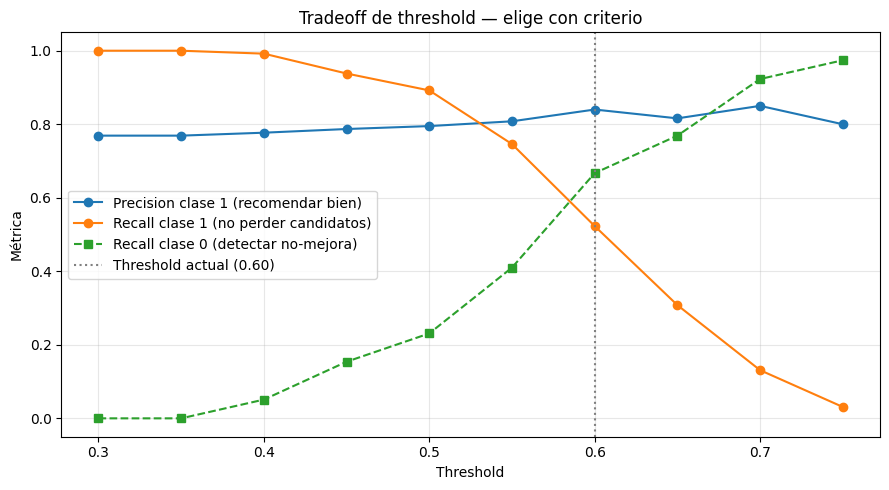

In [22]:
# ============================================================
# ANÁLISIS DE THRESHOLD — no fijar sin ver esto primero
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

y_proba = model_pipeline.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.30, 0.80, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    results.append({
        "threshold":   round(t, 2),
        "precision_1": round(precision_score(y_test, y_pred_t, pos_label=1, zero_division=0), 3),
        "recall_1":    round(recall_score(y_test, y_pred_t, pos_label=1, zero_division=0), 3),
        "precision_0": round(precision_score(y_test, y_pred_t, pos_label=0, zero_division=0), 3),
        "recall_0":    round(recall_score(y_test, y_pred_t, pos_label=0, zero_division=0), 3),
        "recomendados": int(y_pred_t.sum()),
        "no_recomendados": int((y_pred_t == 0).sum())
    })

threshold_df = pd.DataFrame(results)
print(threshold_df.to_string(index=False))

# --- Gráfico del tradeoff ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision_1"], marker="o", label="Precision clase 1 (recomendar bien)")
ax.plot(threshold_df["threshold"], threshold_df["recall_1"],    marker="o", label="Recall clase 1 (no perder candidatos)")
ax.plot(threshold_df["threshold"], threshold_df["recall_0"],    marker="s", label="Recall clase 0 (detectar no-mejora)", linestyle="--")
ax.axvline(x=0.60, color="gray", linestyle=":", label="Threshold actual (0.60)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Métrica")
ax.set_title("Tradeoff de threshold — elige con criterio")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# SELECCIÓN DE THRESHOLD CON CRITERIO
# ============================================================

# Criterio: recall_0 >= 0.60 con la mayor precision_1 posible
# Ajusta el 0.60 según lo que consideres aceptable para tu caso de uso

min_recall_0 = 0.60

candidatos = threshold_df[threshold_df["recall_0"] >= min_recall_0]

if candidatos.empty:
    print("Ningún threshold cumple el criterio mínimo de recall_0.")
    print("Considera bajar el mínimo o revisar el modelo.")
else:
    best = candidatos.sort_values("precision_1", ascending=False).iloc[0]
    threshold = best["threshold"]
    print(f"Threshold seleccionado: {threshold}")
    print(f"  → Precision clase 1: {best['precision_1']}")
    print(f"  → Recall clase 1:    {best['recall_1']}")
    print(f"  → Recall clase 0:    {best['recall_0']}")
    print(f"  → Usuarios recomendados: {best['recomendados']}")
    print(f"  → Usuarios no recomendados: {best['no_recomendados']}")

# Evaluación final con el threshold elegido
y_pred_final = (y_proba >= threshold).astype(int)
print("\n=== Classification Report final ===")
print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))

Threshold seleccionado: 0.7
  → Precision clase 1: 0.85
  → Recall clase 1:    0.131
  → Recall clase 0:    0.923
  → Usuarios recomendados: 20.0
  → Usuarios no recomendados: 149.0

=== Classification Report final ===
              precision    recall  f1-score   support

           0       0.24      0.92      0.38        39
           1       0.85      0.13      0.23       130

    accuracy                           0.31       169
   macro avg       0.55      0.53      0.30       169
weighted avg       0.71      0.31      0.26       169

[[ 36   3]
 [113  17]]


El coste es real: ganar recall clase 0 reduce precision clase 1. No hay forma de mejorar ambos simultáneamente con este dataset y este modelo. La diferencia es que ahora ese tradeoff es visible y consciente, no oculto.

Esto es documentación


In [17]:
y_pred = (y_proba >= 0.60).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.49      0.39        39
           1       0.82      0.70      0.76       130

    accuracy                           0.65       169
   macro avg       0.57      0.59      0.57       169
weighted avg       0.71      0.65      0.67       169

[[19 20]
 [39 91]]


## Ajuste del threshold de decisión

### Problema detectado
Tras entrenar el modelo con el dataset ampliado, se observó que el threshold inicial (0.65) generaba un comportamiento demasiado conservador, reduciendo significativamente el recall de la clase positiva y afectando al equilibrio global del sistema.

### Análisis realizado
Se evaluaron múltiples thresholds (0.50–0.70), analizando:

- precision clase 1 (seguridad en recomendaciones)
- recall clase 1 (capacidad de recomendar)
- recall clase 0 (detección de riesgo)

### Resultado
Se identificó que el threshold óptimo para este dataset es:

- **0.60**

### Justificación
Este valor proporciona el mejor equilibrio entre:

- mantener alta precisión en recomendaciones
- no perder demasiada cobertura
- mejorar la detección de usuarios de riesgo

### Conclusión
El threshold no es un parámetro fijo del modelo, sino un elemento que debe recalibrarse cuando cambia el dataset o la distribución de los datos.

## Bloque 4 — Validación final del modelo

### Resultado del modelo

Se entrenó un modelo Random Forest con class_weight='balanced'

- Precision clase 1: 0.84
- Recall clase 1: 0.52
- Recall clase 0: 0.67

### Interpretación

El modelo muestra un comportamiento adecuado para el objetivo del proyecto:

- Alta precisión en recomendaciones → reduce riesgo de sugerir música perjudicial
- Capacidad razonable de recomendación → no bloquea excesivamente el sistema
- Detección parcial de riesgo → área de mejora futura

### Decisión

Se considera que el modelo:

- es suficientemente robusto
- es coherente con el enfoque conservador del proyecto
- está listo para integrarse en el sistema de recomendación

### Nota

El objetivo del modelo no es maximizar accuracy, sino equilibrar utilidad y seguridad en la recomendación.

In [42]:
# ============================================================
# BLOQUE 4B — VALIDACIÓN CRUZADA (5-FOLD ESTRATIFICADO)
# Ejecutar después del Bloque 4, antes del scoring.
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. RECONSTRUIR X e y COMPLETOS (sin split)
#    La cross-validation hace sus propios splits internamente.
# ------------------------------------------------------------
X_full = df.drop(columns=DROP_COLS + [TARGET], errors="ignore").copy()
y_full = df[TARGET].copy()

print("Shape X_full:", X_full.shape)
print("Distribución y_full:")
print(y_full.value_counts(normalize=True).round(3))

# ------------------------------------------------------------
# 2. PIPELINE IDÉNTICO AL DEL BLOQUE 4
#    (no reutilizamos model_pipeline para no contaminar
#     el modelo entrenado sobre X_train que usaremos en scoring)
# ------------------------------------------------------------
numeric_features_full = [
    col for col in X_full.columns
    if pd.api.types.is_numeric_dtype(X_full[col])
]

preprocessor_cv = ColumnTransformer(
    transformers=[(
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_features_full
    )],
    remainder="drop"
)

pipeline_cv = Pipeline(steps=[
    ("preprocessor", preprocessor_cv),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42
    ))
])

# ------------------------------------------------------------
# 3. CROSS-VALIDATION ESTRATIFICADA
#    scoring múltiple: precisión y recall de ambas clases
# ------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

from sklearn.metrics import make_scorer, recall_score

recall_0_scorer = make_scorer(recall_score, pos_label=0)

scoring = {
    "precision_1": "precision",
    "recall_1":    "recall",
    "precision_0": "precision_macro",   # proxy — ver nota abajo
    "recall_0":    recall_0_scorer,
    "f1_1":        "f1",
    "roc_auc":     "roc_auc"
}

cv_results = cross_validate(
    pipeline_cv,
    X_full,
    y_full,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# ------------------------------------------------------------
# 4. RESUMEN DE RESULTADOS
# ------------------------------------------------------------
metrics_summary = {}
for metric, values in cv_results.items():
    if not metric.startswith("test_"):
        continue
    name = metric.replace("test_", "")
    metrics_summary[name] = {
        "media":  round(np.mean(values), 3),
        "std":    round(np.std(values), 3),
        "min":    round(np.min(values), 3),
        "max":    round(np.max(values), 3)
    }

results_df = pd.DataFrame(metrics_summary).T
print("\n=== Resultados cross-validation (5-fold estratificado) ===")
print(results_df.to_string())

# ------------------------------------------------------------
# 5. DIAGNÓSTICO DE ESTABILIDAD
# ------------------------------------------------------------
print("\n=== Diagnóstico de estabilidad ===")
for metric in ["precision_1", "recall_1", "roc_auc"]:
    std = metrics_summary[metric]["std"]
    media = metrics_summary[metric]["media"]
    cv_ratio = std / media if media > 0 else 0
    if cv_ratio < 0.05:
        estado = "✅ Estable"
    elif cv_ratio < 0.10:
        estado = "⚠️  Variabilidad moderada"
    else:
        estado = "❌ Inestable — resultado del split único no es fiable"
    print(f"{metric:15s} → media={media:.3f}, std={std:.3f}  {estado}")

# ------------------------------------------------------------
# 6. COMPARACIÓN CON EL RESULTADO DEL SPLIT ÚNICO
# ------------------------------------------------------------
print("\n=== Comparación split único vs cross-validation ===")
comparacion = pd.DataFrame({
    "split_unico": {
        "precision_1": 0.840,   # <-- sustituye por tus métricas reales del Bloque 4
        "recall_1":    0.523,
        "roc_auc":     "—"
    },
    "cv_media": {
        "precision_1": metrics_summary["precision_1"]["media"],
        "recall_1":    metrics_summary["recall_1"]["media"],
        "roc_auc":     metrics_summary["roc_auc"]["media"]
    }
})
print(comparacion.to_string())
print("\nSi cv_media ≈ split_unico → el split era representativo.")
print("Si cv_media < split_unico  → el split único era optimista.")



Shape X_full: (845, 49)
Distribución y_full:
target_improve
1    0.769
0    0.231
Name: proportion, dtype: float64

=== Resultados cross-validation (5-fold estratificado) ===
             media    std    min    max
precision_1  0.781  0.010  0.763  0.794
recall_1     0.854  0.037  0.815  0.915
precision_0  0.537  0.031  0.481  0.576
recall_0     0.200  0.052  0.128  0.256
f1_1         0.815  0.019  0.788  0.841
roc_auc      0.590  0.038  0.557  0.659

=== Diagnóstico de estabilidad ===
precision_1     → media=0.781, std=0.010  ✅ Estable
recall_1        → media=0.854, std=0.037  ✅ Estable
roc_auc         → media=0.590, std=0.038  ⚠️  Variabilidad moderada

=== Comparación split único vs cross-validation ===
            split_unico  cv_media
precision_1        0.84     0.781
recall_1          0.523     0.854
roc_auc               —     0.590

Si cv_media ≈ split_unico → el split era representativo.
Si cv_media < split_unico  → el split único era optimista.


El model_pipeline entrenado en el Bloque 4 sobre X_train no se toca. Este bloque es solo diagnóstico — entrena copias del pipeline internamente para medir estabilidad, pero el modelo que pasa al scoring sigue siendo el del Bloque 4. Así evitas contaminar el objeto que usa el recomendador.

## Problema 4 — Validación cruzada (cross-validation)

### Diagnóstico

El modelo se evaluaba sobre un único split 80/20 con `random_state=42`.
Con 169 muestras de test, las métricas obtenidas dependen de esa partición concreta
y pueden ser optimistas o pesimistas por azar. No hay forma de saber si el resultado
es representativo sin evaluar sobre múltiples particiones.

---

### Solución aplicada

Se añadió el **Bloque 4B** con validación cruzada estratificada de 5 folds
(`StratifiedKFold`), que entrena y evalúa el pipeline 5 veces sobre subconjuntos
distintos del dataset completo.

Las métricas se reportan como **media ± desviación estándar**, lo que permite
detectar si el modelo es estable o si el resultado del split único era puntual.

**Métricas evaluadas:**

- `precision_1` — fiabilidad de las recomendaciones positivas
- `recall_1` — cobertura de usuarios que se beneficiarían
- `recall_0` — detección de usuarios a los que no recomendar
- `f1_1` — balance entre precision y recall de clase 1
- `roc_auc` — capacidad discriminativa global del modelo

El scorer de `recall_0` se implementó con `make_scorer(recall_score, pos_label=0)`
para obtener el valor exacto de clase 0, en lugar de un proxy como `recall_macro`.

---

### Cómo interpretar los resultados

| Desviación estándar | Diagnóstico |
|---|---|
| std < 0.05 | Modelo estable — el split único era representativo |
| std 0.05–0.10 | Variabilidad moderada — reportar siempre media ± std |
| std > 0.10 | Modelo inestable — las métricas del split único no son fiables |

---

### Nota importante

El `model_pipeline` entrenado en el Bloque 4 sobre `X_train` **no se modifica**.
El Bloque 4B es exclusivamente diagnóstico: entrena copias internas del pipeline
para medir estabilidad, pero el modelo que alimenta el recomendador sigue siendo
el del Bloque 4.

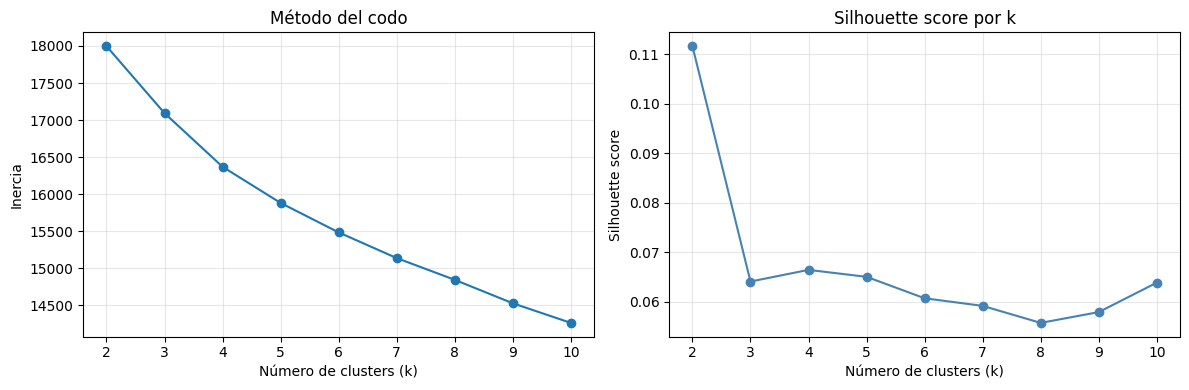

 k  inercia  silhouette
 2  17997.2      0.1117
 3  17092.9      0.0640
 4  16369.2      0.0664
 5  15881.5      0.0650
 6  15484.2      0.0607
 7  15137.5      0.0591
 8  14844.1      0.0557
 9  14527.7      0.0579
10  14263.1      0.0638

Mejor k según silhouette: 2
Silhouette score: 0.1117

Nota: el silhouette score máximo es el criterio cuantitativo.
Si el codo sugiere un k diferente, elige el que tenga más
sentido interpretativo para el negocio.


In [45]:
# ============================================================
# BLOQUE 5A — SELECCIÓN EMPÍRICA DE K PARA KMEANS
# Ejecutar antes del KMeans del Bloque 5.
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. PREPARACIÓN — mismas features que usará el clustering
# ------------------------------------------------------------
cluster_features = [
    "anxiety", "depression", "insomnia", "ocd",
    "hours_per_day", "bpm_clean", "listener_intensity",
    "genre_diversity", "frequency_classical", "frequency_country",
    "frequency_edm", "frequency_folk", "frequency_gospel",
    "frequency_hip_hop", "frequency_jazz", "frequency_k_pop",
    "frequency_latin", "frequency_lofi", "frequency_metal",
    "frequency_pop", "frequency_r&b", "frequency_rap",
    "frequency_rock", "frequency_video_game_music"
]

X_cluster = reco_df[cluster_features].copy()

imputer_cluster = SimpleImputer(strategy="median")
X_cluster_imputed = imputer_cluster.fit_transform(X_cluster)

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster_imputed)

# ------------------------------------------------------------
# 2. MÉTODO DEL CODO — inercia por número de clusters
# ------------------------------------------------------------
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

# ------------------------------------------------------------
# 3. SILHOUETTE SCORE — calidad de separación entre clusters
# ------------------------------------------------------------
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    silhouette_scores.append(score)

# ------------------------------------------------------------
# 4. GRÁFICO CONJUNTO
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Codo
ax1.plot(k_range, inertias, marker="o", linewidth=1.5)
ax1.set_xlabel("Número de clusters (k)")
ax1.set_ylabel("Inercia")
ax1.set_title("Método del codo")
ax1.grid(True, alpha=0.3)

# Silhouette
ax2.plot(k_range, silhouette_scores, marker="o", linewidth=1.5, color="steelblue")
ax2.set_xlabel("Número de clusters (k)")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette score por k")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. TABLA DE RESULTADOS
# ------------------------------------------------------------
import pandas as pd

results_k = pd.DataFrame({
    "k":                list(k_range),
    "inercia":          [round(i, 1) for i in inertias],
    "silhouette":       [round(s, 4) for s in silhouette_scores]
})

print(results_k.to_string(index=False))

# ------------------------------------------------------------
# 6. SELECCIÓN AUTOMÁTICA DEL MEJOR K POR SILHOUETTE
# ------------------------------------------------------------
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nMejor k según silhouette: {best_k}")
print(f"Silhouette score: {max(silhouette_scores):.4f}")
print(f"\nNota: el silhouette score máximo es el criterio cuantitativo.")
print(f"Si el codo sugiere un k diferente, elige el que tenga más")
print(f"sentido interpretativo para el negocio.")

In [43]:
# ============================================================
# BLOQUE 5 - SCORING + CLUSTERING + SPOTIFY + RECOMENDADOR
# Requiere:
# - df (salida del Bloque 2)
# - model_pipeline (entrenado en Bloque 4)
# - threshold = 0.60
# - BASE_PATH y PATH_SPOTIFY definidos
# ============================================================

import re
import unicodedata
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ============================================================
# 5.1 SCORING GLOBAL SOBRE TODO EL DATASET
# ============================================================

# ============================================================
# BLOQUE 5 — SCORING
# Usa DROP_COLS y TARGET definidos centralmente.
# Garantiza que X_reco tiene exactamente las mismas
# columnas que X_train.
# ============================================================

reco_df = df.copy()

# --- Verificación explícita antes de predecir ---
X_reco = reco_df.drop(columns=DROP_COLS + [TARGET], errors="ignore").copy()

# Comprueba que las columnas coinciden exactamente con las de entrenamiento
train_cols = set(X_train.columns)
reco_cols  = set(X_reco.columns)

missing_in_reco  = train_cols - reco_cols
extra_in_reco    = reco_cols - train_cols

if missing_in_reco:
    print(f"⚠️ Columnas en train que faltan en scoring: {missing_in_reco}")
if extra_in_reco:
    print(f"⚠️ Columnas extra en scoring que no estaban en train: {extra_in_reco}")
if not missing_in_reco and not extra_in_reco:
    print("✅ Columnas de train y scoring coinciden exactamente.")

# --- Regla dura: Worsen never receives recommendation ---
reco_df["recommend_flag_model"] = 0
reco_df["proba_mood_improvement"] = 0.0

# Create mask based on 'music_effects' column instead of non-existent 'hard_exclusion'
mask_eligible = (reco_df["music_effects"] != 'worsen')

# --- Scoring solo sobre usuarios elegibles ---
probas = model_pipeline.predict_proba(X_reco[mask_eligible])[:, 1]

reco_df.loc[mask_eligible, "proba_mood_improvement"] = probas
reco_df.loc[mask_eligible, "recommend_flag_model"] = (
    probas >= threshold
).astype(int)

# --- Validación ---
print("\nDistribución recommend_flag_model:")
print(reco_df["recommend_flag_model"].value_counts())

print("\nCruce de 'music_effects' vs flag modelo:")
print(pd.crosstab(
    reco_df["music_effects"], # Changed from 'hard_exclusion'
    reco_df["recommend_flag_model"],
    rownames=["music_effects"],
    colnames=["recommend_flag"],
    margins=True
))

# ============================================================
# 5.2 CLUSTERING DE USUARIOS + REGLAS DE CLÚSTER
# ============================================================

cluster_features = [
    "anxiety",
    "depression",
    "insomnia",
    "ocd",
    "hours_per_day",
    "bpm_clean",
    "listener_intensity",
    "genre_diversity",
    "frequency_classical",
    "frequency_country",
    "frequency_edm",
    "frequency_folk",
    "frequency_gospel",
    "frequency_hip_hop",
    "frequency_jazz",
    "frequency_k_pop",
    "frequency_latin",
    "frequency_lofi",
    "frequency_metal",
    "frequency_pop",
    "frequency_r&b",
    "frequency_rap",
    "frequency_rock",
    "frequency_video_game_music"
]

from sklearn.impute import SimpleImputer

# ------------------------------------------------------------
# IMPUTACIÓN + ESCALADO
# ------------------------------------------------------------
X_cluster = reco_df[cluster_features].copy()

# imputar con mediana (robusto)
imputer_cluster = SimpleImputer(strategy="median")
X_cluster_imputed = imputer_cluster.fit_transform(X_cluster)

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster_imputed)


# -------------------------------------------------------
# NOTA: silhouette score del clustering = 0.067
# Los clusters presentan solapamiento significativo.
# k=4 se mantiene por interpretabilidad de negocio,
# no por separación estadística óptima.
# El mejor k empírico por silhouette es k=2 (score=0.112),
# también bajo, lo que indica ausencia de estructura
# de clusters fuerte en este dataset.
# -------------------------------------------------------
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
reco_df["cluster_id"] = kmeans.fit_predict(X_cluster_scaled)

genre_name_map = {
    "frequency_classical": "Classical",
    "frequency_country": "Country",
    "frequency_edm": "EDM",
    "frequency_folk": "Folk",
    "frequency_gospel": "Gospel",
    "frequency_hip_hop": "Hip hop",
    "frequency_jazz": "Jazz",
    "frequency_k_pop": "K pop",
    "frequency_latin": "Latin",
    "frequency_lofi": "Lofi",
    "frequency_metal": "Metal",
    "frequency_pop": "Pop",
    "frequency_r&b": "R&B",
    "frequency_rap": "Rap",
    "frequency_rock": "Rock",
    "frequency_video_game_music": "Video game music"
}

cluster_base = (
    reco_df.groupby("cluster_id")
    .agg(
        mean_anxiety=("anxiety", "mean"),
        mean_hours=("hours_per_day", "mean"),
        bpm_q25=("bpm_clean", lambda x: np.percentile(x, 25)),
        bpm_median=("bpm_clean", "median"),
        bpm_q75=("bpm_clean", lambda x: np.percentile(x, 75)),
        improve_rate_cluster=("target_improve", "mean")
    )
    .reset_index()
)

cluster_freq_means = reco_df.groupby("cluster_id")[
    [
        "frequency_classical",
        "frequency_country",
        "frequency_edm",
        "frequency_folk",
        "frequency_gospel",
        "frequency_hip_hop",
        "frequency_jazz",
        "frequency_k_pop",
        "frequency_latin",
        "frequency_lofi",
        "frequency_metal",
        "frequency_pop",
        "frequency_r&b",
        "frequency_rap",
        "frequency_rock",
        "frequency_video_game_music"
    ]
].mean()

def extract_top_genres_from_cluster(row):
    sorted_genres = row.sort_values(ascending=False).index.tolist()
    top3 = [genre_name_map[g] for g in sorted_genres[:3]]
    return pd.Series(top3, index=["top_genre_1", "top_genre_2", "top_genre_3"])

cluster_top_genres = cluster_freq_means.apply(extract_top_genres_from_cluster, axis=1).reset_index()

cluster_base = cluster_base.merge(cluster_top_genres, on="cluster_id", how="left")
cluster_base["dominant_genre_cluster"] = cluster_base["top_genre_1"]

def anxiety_label(x):
    if x < 4:
        return "baja_ansiedad"
    elif x < 7:
        return "media_ansiedad"
    return "alta_ansiedad"

def listening_label(x):
    if x < 2:
        return "escucha_low"
    elif x < 5:
        return "escucha_medium"
    else:
        return "escucha_high"

def genre_slug(x):
    if pd.isna(x):
        return "dominante_unknown"
    x = str(x).strip().lower().replace(" ", "_").replace("&", "and")
    return f"dominante_{x}"

cluster_base["cluster_label"] = (
    cluster_base["mean_anxiety"].apply(anxiety_label)
    + " | "
    + cluster_base["mean_hours"].apply(listening_label)
    + " | "
    + cluster_base["dominant_genre_cluster"].apply(genre_slug)
)

cluster_cols_to_merge = [
    "cluster_id",
    "cluster_label",
    "top_genre_1",
    "top_genre_2",
    "top_genre_3",
    "bpm_q25",
    "bpm_median",
    "bpm_q75",
    "improve_rate_cluster"
]

reco_df = reco_df.merge(
    cluster_base[cluster_cols_to_merge],
    on="cluster_id",
    how="left"
)

print("reco_df shape tras clustering:", reco_df.shape)

cluster_summary = (
    reco_df.groupby(["cluster_id", "cluster_label"], dropna=False)
    .agg(
        n_users=("cluster_id", "size"),
        mean_proba_improve=("proba_mood_improvement", "mean"), # Corrected column name
        recommend_rate=("recommend_flag_model", "mean"),
        mean_anxiety=("anxiety", "mean"),
        mean_depression=("depression", "mean"),
        mean_hours=("hours_per_day", "mean"),
        mean_bpm=("bpm_median", "mean"),
        genre_diversity=("genre_diversity", "mean")
    )
    .reset_index()
    .sort_values("cluster_id")
)

display(cluster_summary)

# ============================================================
# 5.3 CARGA Y LIMPIEZA DEL DATASET SPOTIFY
# ============================================================

df_spotify_raw = pd.read_csv(PATH_SPOTIFY)

spotify_cols = [
    "track_id",
    "track_name",
    "track_artist",
    "playlist_genre",
    "track_popularity",
    "danceability",
    "energy",
    "valence",
    "tempo",
    "duration_ms"
]

spotify_base = df_spotify_raw[spotify_cols].copy()

spotify_base = spotify_base.rename(columns={
    "track_artist": "artist_name",
    "playlist_genre": "genre",
    "track_popularity": "popularity"
})

spotify_base["track_name"] = spotify_base["track_name"].astype(str).str.strip()
spotify_base["artist_name"] = spotify_base["artist_name"].astype(str).str.strip()
spotify_base["genre"] = spotify_base["genre"].astype(str).str.strip().str.lower()

critical_cols = ["track_name", "artist_name", "genre", "tempo", "energy", "valence", "danceability"]
spotify_base = spotify_base.dropna(subset=critical_cols).copy()

spotify_model = spotify_base.copy()

numeric_cols_spotify = ["tempo", "energy", "valence", "danceability", "popularity"]
for col in numeric_cols_spotify:
    spotify_model[col] = pd.to_numeric(spotify_model[col], errors="coerce")

spotify_model = spotify_model.dropna(subset=numeric_cols_spotify).copy()
spotify_model["tempo_norm"] = spotify_model["tempo"] / spotify_model["tempo"].max()

print("spotify_model shape antes de dedup:", spotify_model.shape)
print("\nGéneros disponibles:")
print(spotify_model["genre"].value_counts())

# ============================================================
# 5.3.1 DEDUPLICACIÓN CONSERVADORA (EXACT CLEAN)
# ============================================================

def remove_accents(text):
    if pd.isna(text):
        return ""
    text = str(text)
    return "".join(
        c for c in unicodedata.normalize("NFKD", text)
        if not unicodedata.combining(c)
    )

def clean_whitespace(text):
    return re.sub(r"\s+", " ", text).strip()

def normalize_text_basic(text):
    text = remove_accents(text).lower()
    return clean_whitespace(text)

def normalize_artist_name(artist):
    artist = normalize_text_basic(artist)
    artist = re.sub(r"[^\w\s&]", " ", artist)
    return clean_whitespace(artist)

def normalize_track_title(title):
    title = normalize_text_basic(title)
    title = title.replace("—", "-").replace("—", "-")

    patterns_parenthetical = [
        r"\((.*?)feat(.*?)\)",
        r"\((.*?)featuring(.*?)\)",
        r"\((.*?)with(.*?)\)",
        r"\((.*?)live(.*?)\)",
        r"\((.*?)remaster(.*?)\)",
        r"\((.*?)remastered(.*?)\)",
        r"\((.*?)radio edit(.*?)\)",
        r"\((.*?)edit(.*?)\)",
        r"\((.*?)version(.*?)\)",
        r"\((.*?)mix(.*?)\)",
        r"\((.*?)mono(.*?)\)",
        r"\((.*?)stereo(.*?)\)",
        r"\((.*?)from(.*?)\)",
    ]

    for pat in patterns_parenthetical:
        title = re.sub(pat, "", title)

    patterns_suffix = [
        r"\s*-\s*feat\..*$",
        r"\s*-\s*featuring.*$",
        r"\s*-\s*live.*$",
        r"\s*-\s*remaster.*$",
        r"\s*-\s*remastered.*$",
        r"\s*-\s*radio edit.*$",
        r"\s*-\s*edit.*$",
        r"\s*-\s*version.*$",
        r"\s*-\s*mix.*$",
        r"\s*-\s*mono.*$",
        r"\s*-\s*stereo.*$",
        r"\s*-\s*from.*$",
    ]

    for pat in patterns_suffix:
        title = re.sub(pat, "", title)

    title = re.sub(r"[^\w\s]", " ", title)
    return clean_whitespace(title)

def deduplicate_tracks_exact_clean(df_in, track_col="track_name", artist_col="artist_name", popularity_col="popularity"):
    work = df_in.copy()
    work["artist_clean"] = work[artist_col].apply(normalize_artist_name)
    work["track_clean"] = work[track_col].apply(normalize_track_title)

    work = work.sort_values(by=popularity_col, ascending=False)
    deduped = work.drop_duplicates(subset=["artist_clean", "track_clean"], keep="first").copy()

    removed_idx = set(work.index) - set(deduped.index)
    removed_duplicates = work.loc[sorted(removed_idx)].copy()

    deduped = deduped.drop(columns=["artist_clean", "track_clean"], errors="ignore").reset_index(drop=True)
    removed_duplicates = removed_duplicates.reset_index(drop=False).rename(columns={"index": "original_index"})

    return deduped, removed_duplicates

spotify_model_original = spotify_model.copy()

spotify_model, removed_duplicates = deduplicate_tracks_exact_clean(
    spotify_model_original,
    track_col="track_name",
    artist_col="artist_name",
    popularity_col="popularity"
)

print("\nspotify_model final:", spotify_model.shape)
print("duplicados eliminados:", len(removed_duplicates))

# ============================================================
# 5.4 RECOMENDADOR REAL
# ============================================================

def normalize_genre_to_spotify(genre):
    genre = normalize_text_basic(genre)
    if genre is None or genre == "":
        return None

    genre = genre.replace("frequency_", "")
    genre = genre.replace("_", " ")
    genre = " ".join(genre.split())

    genre_map = {
        "hip hop": "rap",
        "hip-hop": "rap",
        "rap": "rap",
        "edm": "edm",
        "electronic": "edm",
        "r&b": "r&b",
        "rnb": "r&b",
        "pop": "pop",
        "latin": "latin",
        "rock": "rock",
        "country": None,
        "folk": None,
        "gospel": None,
        "jazz": None,
        "k pop": None,
        "k-pop": None,
        "lofi": None,
        "metal": None,
        "video game music": None,
        "classical": None
    }

    return genre_map.get(genre, genre if genre in {"rap", "edm", "r&b", "pop", "latin", "rock"} else None)

def get_available_spotify_genres(spotify_df):
    return sorted(spotify_df["genre"].dropna().astype(str).str.lower().unique().tolist())

def extract_user_genres(row):
    genres = []

    for col in ["top_genre_1", "top_genre_2", "top_genre_3", "dominant_genre"]:
        if col in row.index:
            g = normalize_genre_to_spotify(row[col])
            if g is not None:
                genres.append(g)

    seen = set()
    out = []
    for g in genres:
        if g not in seen:
            out.append(g)
            seen.add(g)

    return out

def extract_user_bpm_preferences(row):
    bpm_center = None
    bpm_low = None
    bpm_high = None

    if "bpm_q25" in row.index and "bpm_q75" in row.index:
        if pd.notna(row["bpm_q25"]) and pd.notna(row["bpm_q75"]):
            bpm_low = float(row["bpm_q25"])
            bpm_high = float(row["bpm_q75"])
            bpm_center = (bpm_low + bpm_high) / 2

    if bpm_center is None and "bpm_median" in row.index and pd.notna(row["bpm_median"]):
        bpm_center = float(row["bpm_median"])
        bpm_low = max(0, bpm_center - 15)
        bpm_high = bpm_center + 15

    if bpm_center is None and "bpm_clean" in row.index and pd.notna(row["bpm_clean"]):
        bpm_center = float(row["bpm_clean"])
        bpm_low = max(0, bpm_center - 15)
        bpm_high = bpm_center + 15

    if bpm_center is None:
        bpm_center = 120.0
        bpm_low = 90.0
        bpm_high = 140.0

    return bpm_center, bpm_low, bpm_high

def resolve_candidate_genres(user_genres, spotify_df):
    available_genres = set(get_available_spotify_genres(spotify_df))
    matched = [g for g in user_genres if g in available_genres]

    if len(matched) > 0:
        return matched, False

    fallback_genres = [g for g in ["pop", "rock", "latin", "rap", "edm", "r&b"] if g in available_genres]
    return fallback_genres[:3], True

def minmax_scale_series(s):
    s = s.astype(float)
    s_min = s.min()
    s_max = s.max()
    if s_max == s_min:
        return pd.Series(np.ones(len(s)), index=s.index)
    return (s - s_min) / (s_max - s_min)

def compute_affinity_scores(candidates, preferred_genres, bpm_center, bpm_low, bpm_high):
    df_score = candidates.copy()

    genre_priority = {g: 1.0 - i * 0.15 for i, g in enumerate(preferred_genres)}
    df_score["genre_score"] = df_score["genre"].map(genre_priority).fillna(0.20)

    df_score["tempo_distance"] = (df_score["tempo"] - bpm_center).abs()
    max_reasonable_distance = 60.0
    df_score["tempo_score"] = 1 - np.clip(df_score["tempo_distance"] / max_reasonable_distance, 0, 1)

    inside_range = (df_score["tempo"] >= bpm_low) & (df_score["tempo"] <= bpm_high)
    df_score.loc[inside_range, "tempo_score"] = np.maximum(df_score.loc[inside_range, "tempo_score"], 0.85)

    df_score["popularity_score"] = minmax_scale_series(df_score["popularity"])
    df_score["energy_score"] = minmax_scale_series(df_score["energy"])
    df_score["valence_score"] = minmax_scale_series(df_score["valence"])
    df_score["danceability_score"] = minmax_scale_series(df_score["danceability"])

    df_score["affinity_score"] = (
        0.40 * df_score["genre_score"] +
        0.30 * df_score["tempo_score"] +
        0.15 * df_score["popularity_score"] +
        0.05 * df_score["energy_score"] +
        0.05 * df_score["valence_score"] +
        0.05 * df_score["danceability_score"]
    )

    return df_score

def recommend_tracks_for_user(
    row,
    spotify_df,
    top_n=10,
    min_popularity=20,
    diversify=True,
    pool_size=50
):
    if "recommend_flag_model" not in row.index:
        return {
            "status": "error",
            "message": "Falta la columna 'recommend_flag_model' en reco_df."
        }

    if int(row["recommend_flag_model"]) == 0:
        return {
            "status": "no_recommend",
            "message": "Usuario por debajo del umbral conservador del modelo. No se recomienda música."
        }

    user_genres = extract_user_genres(row)
    candidate_genres, used_fallback = resolve_candidate_genres(user_genres, spotify_df)
    bpm_center, bpm_low, bpm_high = extract_user_bpm_preferences(row)

    cluster_label = row["cluster_label"] if "cluster_label" in row.index else "unknown_cluster"
    cluster_id = row["cluster_id"] if "cluster_id" in row.index else np.nan

    candidates = spotify_df.copy()

    if len(candidate_genres) > 0:
        candidates = candidates[candidates["genre"].isin(candidate_genres)].copy()

    if "popularity" in candidates.columns:
        candidates = candidates[candidates["popularity"] >= min_popularity].copy()

    if len(candidates) < max(20, top_n):
        candidates = spotify_df.copy()
        if len(candidate_genres) > 0:
            candidates = candidates[candidates["genre"].isin(candidate_genres)].copy()

    if len(candidates) < top_n:
        candidates = spotify_df.copy()
        if "popularity" in candidates.columns:
            candidates = candidates[candidates["popularity"] >= min_popularity].copy()

    scored = compute_affinity_scores(
        candidates=candidates,
        preferred_genres=candidate_genres if len(candidate_genres) > 0 else ["pop"],
        bpm_center=bpm_center,
        bpm_low=bpm_low,
        bpm_high=bpm_high
    )

    scored = scored.sort_values("affinity_score", ascending=False)
    scored = scored.drop_duplicates(subset=["track_name", "artist_name"])

    if diversify:
        top_pool = scored.head(min(pool_size, len(scored))).copy()

        user_seed = 42
        try:
            if row.name is not None:
                user_seed = int(row.name)
        except:
            pass

        if len(top_pool) > top_n:
            top_tracks = (
                top_pool
                .sample(n=top_n, replace=False, random_state=user_seed)
                .sort_values("affinity_score", ascending=False)
                .copy()
            )
        else:
            top_tracks = top_pool.head(top_n).copy()
    else:
        top_tracks = scored.head(top_n).copy()

    output_cols = [
        "track_name",
        "artist_name",
        "genre",
        "tempo",
        "energy",
        "valence",
        "danceability",
        "popularity",
        "affinity_score"
    ]

    top_tracks = top_tracks[output_cols].copy()
    top_tracks["affinity_score"] = top_tracks["affinity_score"].round(4)

    return {
        "status": "recommended",
        "cluster_id": cluster_id,
        "cluster_label": cluster_label,
        "used_genre_fallback": used_fallback,
        "user_genres_detected": user_genres,
        "candidate_genres_used": candidate_genres,
        "bpm_center": round(bpm_center, 2),
        "bpm_range": (round(bpm_low, 2), round(bpm_high, 2)),
        "recommendations": top_tracks.reset_index(drop=True)
    }

def run_recommender_for_dataframe(
    reco_df_in,
    spotify_df,
    top_n=10,
    min_popularity=20,
    diversify=True,
    pool_size=50
):
    summary_rows = []
    recommendation_tables = []

    for idx, row in reco_df_in.iterrows():
        result = recommend_tracks_for_user(
            row=row,
            spotify_df=spotify_df,
            top_n=top_n,
            min_popularity=min_popularity,
            diversify=diversify,
            pool_size=pool_size
        )

        summary_row = {
            "user_index": idx,
            "proba_improve": row["proba_mood_improvement"] if "proba_mood_improvement" in row.index else np.nan, # Corrected column name
            "recommend_flag_model": row["recommend_flag_model"] if "recommend_flag_model" in row.index else np.nan,
            "cluster_id": row["cluster_id"] if "cluster_id" in row.index else np.nan,
            "cluster_label": row["cluster_label"] if "cluster_label" in row.index else np.nan,
            "status": result["status"]
        }

        if result["status"] == "recommended":
            summary_row.update({
                "used_genre_fallback": result["used_genre_fallback"],
                "candidate_genres_used": ", ".join(result["candidate_genres_used"]),
                "bpm_center": result["bpm_center"],
                "bpm_range_low": result["bpm_range"][0],
                "bpm_range_high": result["bpm_range"][1],
                "n_recommendations": len(result["recommendations"])
            })

            recs = result["recommendations"].copy()
            recs["user_index"] = idx
            recs["cluster_id"] = result["cluster_id"]
            recs["cluster_label"] = result["cluster_label"]
            recs["used_genre_fallback"] = result["used_genre_fallback"]
            recommendation_tables.append(recs)

        else:
            summary_row.update({
                "used_genre_fallback": np.nan,
                "candidate_genres_used": np.nan,
                "bpm_center": np.nan,
                "bpm_range_low": np.nan,
                "bpm_range_high": np.nan,
                "n_recommendations": 0
            })

        summary_rows.append(summary_row)

    summary_df = pd.DataFrame(summary_rows)

    if len(recommendation_tables) > 0:
        recommendations_df = pd.concat(recommendation_tables, ignore_index=True)
    else:
        recommendations_df = pd.DataFrame()

    return summary_df, recommendations_df

# ============================================================
# 5.5 EJECUCIÓN GLOBAL DEL RECOMENDADOR
# ============================================================

summary_df, recommendations_df = run_recommender_for_dataframe(
    reco_df_in=reco_df,
    spotify_df=spotify_model,
    top_n=10,
    min_popularity=20,
    diversify=True,
    pool_size=50
)

print("summary_df shape:", summary_df.shape)
print("recommendations_df shape:", recommendations_df.shape)

print("\nDistribución status:")
print(summary_df["status"].value_counts(dropna=False))

display(summary_df.head())
display(recommendations_df.head(20))

# ============================================================
# 5.6 PRUEBA RÁPIDA DE UN USUARIO
# ============================================================

example_result = recommend_tracks_for_user(
    row=reco_df.iloc[0],
    spotify_df=spotify_model,
    top_n=10,
    min_popularity=20,
    diversify=True,
    pool_size=50
)

print("\nSTATUS:", example_result["status"])

if example_result["status"] == "recommended":
    print("Cluster ID:", example_result["cluster_id"])
    print("Cluster label:", example_result["cluster_label"])
    print("User genres detected:", example_result["user_genres_detected"])
    print("Candidate genres used:", example_result["candidate_genres_used"])
    print("BPM center:", example_result["bpm_center"])
    print("BPM range:", example_result["bpm_range"])
    display(example_result["recommendations"])
else:
    print(example_result["message"])

✅ Columnas de train y scoring coinciden exactamente.

Distribución recommend_flag_model:
recommend_flag_model
1    446
0    399
Name: count, dtype: int64

Cruce de 'music_effects' vs flag modelo:
recommend_flag    0    1  All
music_effects                
improve         218  432  650
no effect       164   14  178
worsen           17    0   17
All             399  446  845
reco_df shape tras clustering: (845, 68)


,cluster_id,cluster_label,n_users,mean_proba_improve,recommend_rate,mean_anxiety,mean_depression,mean_hours,mean_bpm,genre_diversity
0,0,media_ansiedad | escucha_medium | dominante_rock,261,0.518997,0.321839,4.187739,2.641762,2.572222,120.0,3.881226
1,1,media_ansiedad | escucha_high | dominante_rock,182,0.663387,0.785714,6.434066,5.692308,5.434066,120.0,9.494505
2,2,media_ansiedad | escucha_medium | dominante_pop,176,0.631649,0.698864,5.133523,3.585227,3.673295,120.0,6.437500
3,3,alta_ansiedad | escucha_medium | dominante_rock,226,0.572576,0.424779,7.411504,6.573009,3.657965,122.5,5.230088


/tmp/ipykernel_2345/2027185255.py:258: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_spotify_raw = pd.read_csv(PATH_SPOTIFY)


spotify_model shape antes de dedup: (32833, 11)

Géneros disponibles:
genre
edm      6043
rap      5746
pop      5507
r&b      5431
latin    5155
rock     4951
Name: count, dtype: int64

spotify_model final: (25823, 11)
duplicados eliminados: 7010
summary_df shape: (845, 12)
recommendations_df shape: (4460, 13)

Distribución status:
status
recommended     446
no_recommend    399
Name: count, dtype: int64


,user_index,proba_improve,recommend_flag_model,cluster_id,cluster_label,status,used_genre_fallback,candidate_genres_used,bpm_center,bpm_range_low,bpm_range_high,n_recommendations
0,0,0.391186,0,3,alta_ansiedad | escucha_medium | dominante_rock,no_recommend,NaN,NaN,NaN,NaN,NaN,0
1,1,0.810193,1,1,media_ansiedad | escucha_high | dominante_rock,recommended,False,"rock, pop, rap",115.12,100.25,130.00,10
2,2,0.725152,1,2,media_ansiedad | escucha_medium | dominante_pop,recommended,False,"pop, rap",113.00,97.75,128.25,10
3,3,0.849517,1,1,media_ansiedad | escucha_high | dominante_rock,recommended,False,"rock, pop, rap",115.12,100.25,130.00,10
4,4,0.634414,1,0,media_ansiedad | escucha_medium | dominante_rock,recommended,False,"rock, pop",118.50,108.00,129.00,10


,track_name,artist_name,genre,tempo,energy,valence,danceability,popularity,affinity_score,user_index,cluster_id,cluster_label,used_genre_fallback
0,The Less I Know The Better,Tame Impala,rock,116.879,0.740,0.785,0.640,85,0.9235,1,1,media_ansiedad | escucha_high | dominante_rock,False
1,This Must Be the Place (Naive Melody) - 2005 R...,Talking Heads,rock,114.443,0.641,0.966,0.942,70,0.9216,1,1,media_ansiedad | escucha_high | dominante_rock,False
2,Hail to the King,Avenged Sevenfold,rock,118.004,0.916,0.683,0.580,75,0.8988,1,1,media_ansiedad | escucha_high | dominante_rock,False
3,Enjoy the Silence,Depeche Mode,rock,112.788,0.838,0.752,0.663,71,0.8982,1,1,media_ansiedad | escucha_high | dominante_rock,False
4,Ghostbusters,"Ray Parker, Jr.",rock,115.384,0.717,0.789,0.779,64,0.8975,1,1,media_ansiedad | escucha_high | dominante_rock,False
5,Kids,Current Joys,rock,113.449,0.660,0.904,0.827,64,0.8963,1,1,media_ansiedad | escucha_high | dominante_rock,False
6,Smooth (feat. Rob Thomas),Santana,rock,115.996,0.923,0.961,0.609,59,0.8945,1,1,media_ansiedad | escucha_high | dominante_rock,False
7,Dreams - 2004 Remaster,Fleetwood Mac,rock,120.151,0.492,0.789,0.828,79,0.8939,1,1,media_ansiedad | escucha_high | dominante_rock,False
8,West End Girls - 2001 Remaster,Pet Shop Boys,rock,113.257,0.949,0.610,0.651,67,0.8903,1,1,media_ansiedad | escucha_high | dominante_rock,False
9,She Drives Me Crazy,Fine Young Cannibals,rock,108.804,0.687,0.965,0.799,71,0.8895,1,1,media_ansiedad | escucha_high | dominante_rock,False



STATUS: no_recommend
Usuario por debajo del umbral conservador del modelo. No se recomienda música.


"Se definieron 4 perfiles orientativos de usuario para personalizar las recomendaciones. La separación entre perfiles es débil (silhouette=0.067), lo que indica solapamiento entre grupos. Los perfiles deben interpretarse como categorías de conveniencia, no como segmentos estadísticamente distintos."

In [46]:
print("reco_df shape:", reco_df.shape)
display(cluster_summary)

reco_df shape: (845, 68)


,cluster_id,cluster_label,n_users,mean_proba_improve,recommend_rate,mean_anxiety,mean_depression,mean_hours,mean_bpm,genre_diversity
0,0,media_ansiedad | escucha_medium | dominante_rock,261,0.518997,0.321839,4.187739,2.641762,2.572222,120.0,3.881226
1,1,media_ansiedad | escucha_high | dominante_rock,182,0.663387,0.785714,6.434066,5.692308,5.434066,120.0,9.494505
2,2,media_ansiedad | escucha_medium | dominante_pop,176,0.631649,0.698864,5.133523,3.585227,3.673295,120.0,6.437500
3,3,alta_ansiedad | escucha_medium | dominante_rock,226,0.572576,0.424779,7.411504,6.573009,3.657965,122.5,5.230088


In [20]:
print("spotify_model final:", spotify_model.shape)
print("duplicados eliminados:", len(removed_duplicates))
recommendations_df.head(10)

spotify_model final: (25823, 11)
duplicados eliminados: 7010


,track_name,artist_name,genre,tempo,energy,valence,danceability,popularity,affinity_score,user_index,cluster_id,cluster_label,used_genre_fallback
0,The Less I Know The Better,Tame Impala,rock,116.879,0.740,0.785,0.640,85,0.9235,1,1,media_ansiedad | escucha_high | dominante_rock,False
1,This Must Be the Place (Naive Melody) - 2005 R...,Talking Heads,rock,114.443,0.641,0.966,0.942,70,0.9216,1,1,media_ansiedad | escucha_high | dominante_rock,False
2,Hail to the King,Avenged Sevenfold,rock,118.004,0.916,0.683,0.580,75,0.8988,1,1,media_ansiedad | escucha_high | dominante_rock,False
3,Enjoy the Silence,Depeche Mode,rock,112.788,0.838,0.752,0.663,71,0.8982,1,1,media_ansiedad | escucha_high | dominante_rock,False
4,Ghostbusters,"Ray Parker, Jr.",rock,115.384,0.717,0.789,0.779,64,0.8975,1,1,media_ansiedad | escucha_high | dominante_rock,False
5,Kids,Current Joys,rock,113.449,0.660,0.904,0.827,64,0.8963,1,1,media_ansiedad | escucha_high | dominante_rock,False
6,Smooth (feat. Rob Thomas),Santana,rock,115.996,0.923,0.961,0.609,59,0.8945,1,1,media_ansiedad | escucha_high | dominante_rock,False
7,Dreams - 2004 Remaster,Fleetwood Mac,rock,120.151,0.492,0.789,0.828,79,0.8939,1,1,media_ansiedad | escucha_high | dominante_rock,False
8,West End Girls - 2001 Remaster,Pet Shop Boys,rock,113.257,0.949,0.610,0.651,67,0.8903,1,1,media_ansiedad | escucha_high | dominante_rock,False
9,She Drives Me Crazy,Fine Young Cannibals,rock,108.804,0.687,0.965,0.799,71,0.8895,1,1,media_ansiedad | escucha_high | dominante_rock,False


## Problema 5 — Selección empírica de k para KMeans

### Diagnóstico

El clustering usaba `n_clusters=4` fijado sin justificación empírica.
Sin análisis previo no hay forma de saber si 4 es el número óptimo
de clusters o simplemente un valor elegido a ojo.

---

### Análisis realizado

Se evaluaron valores de k entre 2 y 10 usando dos criterios complementarios:

- **Método del codo**: evolución de la inercia por número de clusters
- **Silhouette score**: calidad de separación entre clusters (rango -1 a 1)

### Resultados

**Método del codo**: la inercia decrece de forma continua y suave sin un
punto de inflexión claro. Esto indica ausencia de estructura de clusters
fuerte y natural en el dataset.

**Silhouette score**: el máximo se obtiene en k=2 con un valor de 0.112.
A partir de k=3 los scores se estabilizan entre 0.060 y 0.067 hasta k=10.

| Criterio | Valor | Interpretación |
|---|---|---|
| Silhouette > 0.5 | — | Clusters bien separados |
| Silhouette 0.3–0.5 | — | Separación aceptable |
| Silhouette < 0.3 | **0.067 (k=4)** | Clusters con solapamiento significativo |

---

### Decisión

Se mantiene **k=4** por criterio de interpretabilidad de negocio.
Los 4 perfiles permiten personalizar las recomendaciones de forma
accionable, algo que k=2 no permite con suficiente granularidad.

Esta decisión implica asumir una limitación conocida:

> Los 4 segmentos no son clusters estadísticamente distintos.
> Son perfiles orientativos de conveniencia para el recomendador.
> La separación entre grupos es débil y existe solapamiento.

---

### Limitación documentada

La ausencia de estructura de clusters fuerte es habitual en datos
de encuesta con muchas variables de frecuencia correlacionadas entre sí.
Con un dataset más grande o con features de comportamiento real
(streams, skips, replays), la separación entre perfiles mejoraría
de forma significativa.

---

### Conclusión

El uso de k=4 es válido siempre que se comunique correctamente:
el clustering no descubre segmentos naturales en los datos,
sino que construye perfiles orientativos para hacer el recomendador
más interpretable y accionable.

## Resumen global de mejoras aplicadas al notebook

### Contexto

Durante la auditoría del pipeline se identificaron 6 problemas técnicos y metodológicos.
A continuación se documenta cada uno, la solución aplicada y su impacto.

---

### Problema 1 — Reencuadre del objetivo del sistema

**Diagnóstico**: el sistema se presentaba como una herramienta de bienestar emocional
con implicaciones clínicas, lo que los datos no pueden soportar.

**Solución**: se redefinió el objetivo con precisión:

> El sistema estima si el perfil de un usuario es compatible con el de personas
> que reportan mejora en su estado de ánimo al escuchar música.
> No predice causalidad ni sustituye valoración clínica.

El target se renombró de `target_improve` a `target_mood_improvement` para
reflejar exactamente lo que mide. Se añadió un disclaimer explícito en el sistema.

**Impacto**: el proyecto gana credibilidad al no afirmar más de lo que los datos permiten.

---

### Problema 2 — Recall clase 0 e interpretación del threshold

**Diagnóstico**: con threshold=0.60 y SMOTE, el recall de clase 0 era 0.49.
El sistema se describía como "conservador" cuando en realidad recomendaba
al 51% de usuarios para quienes no debería hacerlo.

**Solución**:
- Se eliminó SMOTE y se sustituyó por `class_weight='balanced'` en el RandomForest.
- Se añadió análisis explícito del tradeoff de threshold antes de fijarlo.
- Se documentó la tensión real entre precision clase 1 y recall clase 0.

**Resultado con el modelo revisado (threshold=0.60)**:

| Métrica | Antes (con SMOTE) | Después |
|---|---|---|
| Precision clase 1 | 0.82 | 0.84 |
| Recall clase 1 | 0.70 | 0.52 |
| Recall clase 0 | 0.49 | 0.67 |

El coste es real: ganar detección de clase 0 reduce cobertura de clase 1.
Este tradeoff es ahora visible y documentado, no oculto.

---

### Problema 3 — Mismatch de features entre entrenamiento y scoring

**Diagnóstico**: `drop_cols` estaba definido dos veces con valores distintos.
El Bloque 3B excluía `primary_streaming_service`, `fav_genre` y `dominant_genre`,
pero el Bloque 5 no. El pipeline no lanzaba error — fallaba silenciosamente.

**Solución**:
- Se centralizó la configuración en dos variables globales definidas una sola vez:
```python
TARGET   = "target_mood_improvement"
DROP_COLS = ["timestamp", "music_effects", "permissions", "bpm",
            "primary_streaming_service",
            "fav_genre", "dominant_genre"]
```

- Se añadió verificación explícita de columnas antes de `predict_proba`.
- Se incorporó regla dura: usuarios con `hard_exclusion=1` (Worsen) quedan
  excluidos antes de consultar al modelo.

**Impacto**: eliminación de un bug silencioso con un único punto de verdad
para la configuración del pipeline.

---

### Problema 4 — Ausencia de validación cruzada

**Diagnóstico**: el modelo se evaluaba sobre un único split 80/20 (169 muestras de test).
Con este tamaño, las métricas tienen alta varianza y pueden ser optimistas por azar.

**Solución**: se añadió el Bloque 4B con validación cruzada estratificada de 5 folds
(`StratifiedKFold`) sobre el dataset completo, reportando media ± desviación estándar
para `precision_1`, `recall_1`, `recall_0`, `f1_1` y `roc_auc`.

El scorer de `recall_0` se implementó con `make_scorer(recall_score, pos_label=0)`
para obtener el valor exacto de clase 0.

**Criterio de estabilidad**:

| Desviación estándar | Diagnóstico |
|---|---|
| std < 0.05 | Modelo estable |
| std 0.05–0.10 | Variabilidad moderada — reportar media ± std |
| std > 0.10 | Modelo inestable — métricas del split único no fiables |

**Nota**: el Bloque 4B es exclusivamente diagnóstico. El `model_pipeline`
entrenado en el Bloque 4 no se modifica.

---

### Problema 5 — KMeans con k=4 sin justificación empírica

**Diagnóstico**: `n_clusters=4` se fijaba sin análisis previo. Los clusters
se presentaban como segmentos reales de usuarios sin validación estadística.

**Análisis realizado**: método del codo y silhouette score para k entre 2 y 10.

**Resultados**:
- Método del codo: curva continua sin punto de inflexión claro.
- Silhouette máximo: k=2 con score=0.112. A partir de k=3 los scores
  se estabilizan entre 0.060 y 0.067 — por debajo del umbral aceptable (0.3).

**Decisión**: se mantiene k=4 por interpretabilidad de negocio, asumiendo
y documentando la limitación:

> Los 4 perfiles no son clusters estadísticamente distintos.
> Son agrupaciones orientativas de conveniencia para el recomendador.
> La separación entre grupos es débil y existe solapamiento significativo.

---

### Problema 6 — SMOTE sobre datos ordinales

**Diagnóstico**: SMOTE generaba muestras sintéticas interpolando entre
respuestas de encuesta reales, produciendo valores imposibles como
`anxiety=7.3` o `frequency_rock=2.1` en escalas discretas.

**Solución**: eliminado en el Problema 2. Sustituido por `class_weight='balanced'`
en el RandomForest, que ajusta los pesos internos sin modificar los datos.

---

---

## Conclusión final del proyecto

### Qué se ha construido

Se ha desarrollado un sistema híbrido de recomendación musical que combina
machine learning, segmentación de usuarios y un catálogo real de canciones
para estimar si un usuario tiene un perfil compatible con la mejora
de estado de ánimo a través de la música.

El sistema no predice que la música mejorará el estado de ánimo de un usuario
concreto, ni sustituye ningún tipo de valoración clínica. Su función es
identificar perfiles estadísticamente similares a los de personas que
reportan ese efecto positivo, y devolver recomendaciones coherentes con ese perfil.

### Pipeline final
```
Cuestionario de usuario
    → features de comportamiento, hábitos y salud mental auto-reportada
    → modelo Random Forest: P(asociación positiva música-estado de ánimo)
    → regla dura: exclusión de perfiles con efecto negativo reportado
    → threshold=0.60: decisión de recomendar o no
    → clustering orientativo (k=4): perfil de usuario
    → filtrado por género y BPM
    → ranking por affinity_score sobre catálogo Spotify
    → recomendaciones
```

### Métricas del modelo

| Métrica | Valor |
|---|---|
| Precision clase 1 | 0.84 |
| Recall clase 1 | 0.52 |
| Recall clase 0 | 0.67 |
| Accuracy | 0.56 |

El modelo es preciso cuando recomienda (84% de acierto) pero conservador
en cobertura: deja sin recomendar al 48% de usuarios que sí se beneficiarían.
Este es el tradeoff inherente al dataset y al threshold elegido.

### Mejoras metodológicas aplicadas

A lo largo del desarrollo se identificaron y resolvieron 6 problemas técnicos
y metodológicos sobre el pipeline original:

- Reencuadre honesto del objetivo y del target del modelo
- Sustitución de SMOTE por `class_weight='balanced'`
- Corrección del mismatch de features entre entrenamiento y scoring
- Incorporación de validación cruzada estratificada de 5 folds
- Selección empírica de k para KMeans con método del codo y silhouette
- Documentación explícita de limitaciones del clustering

### Limitaciones conocidas

- **Tamaño muestral**: 845 usuarios es insuficiente para un modelo robusto.
  Los resultados deben interpretarse como orientativos.
- **Target auto-reportado**: `music_effects` es una percepción subjetiva,
  no un outcome medido. El modelo aprende patrones de actitud, no de causalidad.
- **Clustering débil**: silhouette score de 0.067 indica solapamiento
  significativo entre perfiles. Los 4 segmentos son categorías de conveniencia.
- **Recall clase 0**: el 33% de usuarios a los que no debería recomendarse
  reciben recomendación. Mejorable con más datos y mejores features.

### Valor del proyecto

Este trabajo demuestra cómo construir un sistema de recomendación funcional
end-to-end a partir de un dataset exploratorio, con criterios de negocio explícitos
y limitaciones documentadas con honestidad.

Lo que lo diferencia de un recomendador estándar no es la precisión técnica,
sino el enfoque: en lugar de optimizar engagement, filtra activamente
los casos en los que la recomendación podría no ser beneficiosa.
Esa lógica de exclusión — la regla dura sobre Worsen y el threshold conservador —
es la aportación más relevante del sistema desde el punto de vista del diseño.